In [4]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score


   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
feature_df = pd.read_csv('feature_data.csv') # You can use the test file here and comment the next line
operation_df = pd.read_csv('operational_dataset.csv')
feature_df.set_index('Date', inplace=True)
operation_df.set_index('Date', inplace=True)

In [36]:
operation_df['destination'] = operation_df['target']

In [37]:
# Join feature_df and operation_df on Date, source, and destination
merged_df = feature_df.merge(operation_df, on=['Date', 'source', 'destination'], how='inner')

# Display the merged dataframe
merged_df.drop(columns=['target'], axis=1, inplace=True)
feature_df = merged_df

In [38]:
never_disrupted = feature_df[feature_df['Total_disruptions'] == 0]

print("Mean and median of rides planned for never disrupted trajectories:")
print(np.mean(never_disrupted['Total_rides']))
print(np.median(never_disrupted['Total_rides']))
print("Mean and median of rides planned for disrupted trajectories:")
print(np.mean(feature_df[feature_df['Total_disruptions'] > 0]['Total_rides']))
print(np.median(feature_df[feature_df['Total_disruptions'] > 0]['Total_rides']))
print("Percentage of never disrupted trajectories:")
perc = 37637 / 612790 * 100
print(perc)

# Remove never disrupted trajectories
feature_df = feature_df[feature_df['Total_disruptions'] > 0]

Mean and median of rides planned for never disrupted trajectories:
718.5161410314319
54.0
Mean and median of rides planned for disrupted trajectories:
12311.730057915025
4472.0
Percentage of never disrupted trajectories:
6.14190832095824


In [135]:
sources = feature_df['source'].unique()
destinations = feature_df['destination'].unique()
stations = list(set(sources).union(set(destinations)))
print(len(stations), "stations in the dataset")

244 stations in the dataset


In [39]:
print(feature_df)

                        source         destination  source_degree  \
Date                                                                
2019-01-01    's-Hertogenbosch          Roosendaal             14   
2019-01-01    's-Hertogenbosch    Utrecht Centraal             14   
2019-01-01   Den Haag Centraal  Eindhoven Centraal             29   
2019-01-01   Den Haag Centraal    Utrecht Centraal             29   
2019-01-01  Eindhoven Centraal   Den Haag Centraal             21   
...                        ...                 ...            ...   
2024-12-31              Zwolle    Lelystad Centrum             23   
2024-12-31              Zwolle            Nijmegen             23   
2024-12-31              Zwolle          Roosendaal             23   
2024-12-31              Zwolle    Utrecht Centraal             23   
2024-12-31              Zwolle             Zutphen             23   

            source_weighted_degree  source_avg_distance  target_degree  \
Date                        

In [244]:
feature_df.to_csv('final_feature_df.csv', index=True)

In [40]:
# Define seasons based on date ranges
def get_season(date):
    if (date.month == 12 and date.day >= 21) or (date.month <= 3 and date.day <= 20):
        return 'Winter'
    elif (date.month == 3 and date.day >= 21) or (date.month <= 6 and date.day <= 20):
        return 'Spring'
    elif (date.month == 6 and date.day >= 21) or (date.month <= 9 and date.day <= 20):
        return 'Summer'
    elif (date.month == 9 and date.day >= 21) or (date.month <= 12 and date.day <= 20):
        return 'Autumn'

feature_df['Date'] = pd.to_datetime(feature_df.index)

feature_df['Season'] = feature_df['Date'].apply(get_season)

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2645303035.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df['Date'] = pd.to_datetime(feature_df.index)
C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2645303035.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df['Season'] = feature_df['Date'].apply(get_season)


In [8]:
# Split feature_df by season
seasonal_dfs = {season: df for season, df in feature_df.groupby('Season')}

# Example: Access the DataFrame for Winter
winter_df = seasonal_dfs['Winter']
print(winter_df)

                        source         destination  source_degree  \
Date                                                                
2019-01-01    's-Hertogenbosch          Roosendaal             14   
2019-01-01    's-Hertogenbosch    Utrecht Centraal             14   
2019-01-01   Den Haag Centraal  Eindhoven Centraal             29   
2019-01-01   Den Haag Centraal    Utrecht Centraal             29   
2019-01-01  Eindhoven Centraal   Den Haag Centraal             21   
...                        ...                 ...            ...   
2024-12-31              Zwolle    Lelystad Centrum             23   
2024-12-31              Zwolle            Nijmegen             23   
2024-12-31              Zwolle          Roosendaal             23   
2024-12-31              Zwolle    Utrecht Centraal             23   
2024-12-31              Zwolle             Zutphen             23   

            source_weighted_degree  source_avg_distance  target_degree  \
Date                        

In [9]:
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal_splits = {}
seasonal_ys = {}
for season in seasons:
    dataset = seasonal_dfs[season]
    seasonal_splits[season] = dataset

print(seasonal_splits['Winter'])

                        source         destination  source_degree  \
Date                                                                
2019-01-01    's-Hertogenbosch          Roosendaal             14   
2019-01-01    's-Hertogenbosch    Utrecht Centraal             14   
2019-01-01   Den Haag Centraal  Eindhoven Centraal             29   
2019-01-01   Den Haag Centraal    Utrecht Centraal             29   
2019-01-01  Eindhoven Centraal   Den Haag Centraal             21   
...                        ...                 ...            ...   
2024-12-31              Zwolle    Lelystad Centrum             23   
2024-12-31              Zwolle            Nijmegen             23   
2024-12-31              Zwolle          Roosendaal             23   
2024-12-31              Zwolle    Utrecht Centraal             23   
2024-12-31              Zwolle             Zutphen             23   

            source_weighted_degree  source_avg_distance  target_degree  \
Date                        

In [10]:
def split_season_by_year(df_season, season_name):
    """
    Split a seasonal DataFrame (e.g., all Winters) into separate DataFrames by year.

    Parameters:
    - df_season: A DataFrame indexed by datetime, containing data for one season over multiple years
    - season_name: The name of the season ('Spring', 'Summer', 'Fall', 'Winter')

    Returns:
    - Dictionary with keys like 'Winter 2019', 'Winter 2020', etc., and values as DataFrames
    """
    df_season = df_season.sort_index()
    df_season.index = pd.to_datetime(df_season.index)

    seasonal_splits = {}

    years = sorted(set(df_season.index.year))

    for year in years:
        if season_name == 'Winter':
            # Winter spans two years: Dec 21 (year) to Mar 20 (year + 1)
            start = pd.Timestamp(f'{year}-12-21')
            end = pd.Timestamp(f'{year + 1}-03-20')
            label = f'Winter {year}'
        elif season_name == 'Spring':
            start = pd.Timestamp(f'{year}-03-21')
            end = pd.Timestamp(f'{year}-06-20')
            label = f'Spring {year}'
        elif season_name == 'Summer':
            start = pd.Timestamp(f'{year}-06-21')
            end = pd.Timestamp(f'{year}-09-20')
            label = f'Summer {year}'
        elif season_name == 'Autumn':
            start = pd.Timestamp(f'{year}-09-21')
            end = pd.Timestamp(f'{year}-12-20')
            label = f'Autumn {year}'
        else:
            raise ValueError(f"Unknown season: {season_name}")

        mask = (df_season.index >= start) & (df_season.index <= end)
        split_df = df_season.loc[mask]

        if not split_df.empty:
            seasonal_splits[label] = split_df

    return seasonal_splits

In [11]:
winter_data = split_season_by_year(seasonal_splits['Winter'], 'Winter')
spring_data = split_season_by_year(seasonal_splits['Spring'], 'Spring')
# Access a specific season:
winter_2023 = winter_data['Winter 2023']
print(winter_2023)

# Loop through all:
for season, data in winter_data.items():
    print(season, data.shape)

for season, data in spring_data.items():
    print(season, data.shape)

                      source         destination  source_degree  \
Date                                                              
2023-12-21  's-Hertogenbosch     Arnhem Centraal             16   
2023-12-21  's-Hertogenbosch   Den Haag Centraal             16   
2023-12-21  's-Hertogenbosch              Deurne             16   
2023-12-21  's-Hertogenbosch           Dordrecht             16   
2023-12-21  's-Hertogenbosch  Eindhoven Centraal             16   
...                      ...                 ...            ...   
2024-03-20            Zwolle    Lelystad Centrum             19   
2024-03-20            Zwolle            Nijmegen             19   
2024-03-20            Zwolle          Roosendaal             19   
2024-03-20            Zwolle  Rotterdam Centraal             19   
2024-03-20            Zwolle    Utrecht Centraal             19   

            source_weighted_degree  source_avg_distance  target_degree  \
Date                                                  

In [13]:
feature_df[feature_df['Disrupted']]

,source,destination,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,...,Disrupted,Days_since_last_disruption,Num_prev_disruptions,Ratio,Total_disruptions,Total_rides,Previous_causes_vec,Most_recent_causes_vec,Date,Season
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,'s-Hertogenbosch,Roosendaal,14,83,31.714286,13,52,39.230769,2,0.142857,...,True,0,0,0.000000,1,2,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2019-01-01,Winter
2019-01-01,'s-Hertogenbosch,Utrecht Centraal,14,83,31.714286,36,243,21.305556,2,0.071429,...,True,0,0,0.000000,2,1,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. ...,2019-01-01,Winter
2019-01-01,Den Haag Centraal,Eindhoven Centraal,29,253,52.793103,21,116,40.142857,3,0.111111,...,True,0,0,0.000000,1,32,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2019-01-01,Winter
2019-01-01,Den Haag Centraal,Utrecht Centraal,29,253,52.793103,36,243,21.305556,10,0.333333,...,True,0,0,0.000000,1,21,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2019-01-01,Winter
2019-01-01,Eindhoven Centraal,Den Haag Centraal,21,116,40.142857,29,253,52.793103,3,0.111111,...,True,0,0,0.000000,1,32,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2019-01-01,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,Lelystad Centrum,Rotterdam Centraal,15,78,59.133333,27,139,35.407407,2,0.083333,...,True,5,25,2.682403,26,932,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2024-12-31,Winter
2024-12-31,Rotterdam Centraal,Lelystad Centrum,27,139,35.407407,15,78,59.133333,2,0.083333,...,True,5,107,5.171580,108,2069,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2024-12-31,Winter
2024-12-31,Rotterdam Centraal,Utrecht Centraal,27,139,35.407407,40,226,15.375000,5,0.131579,...,True,1,897,1.519644,898,59027,[1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2024-12-31,Winter


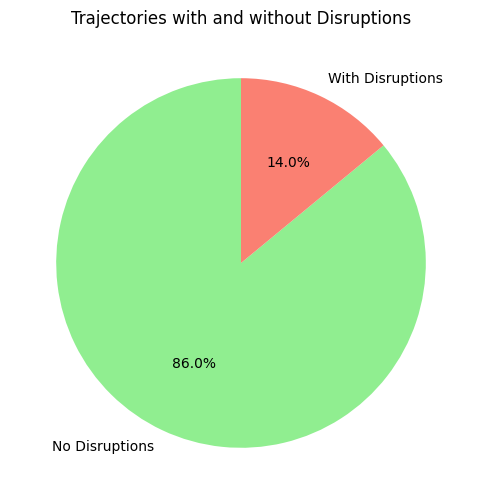

In [41]:
disrupted = (feature_df["Disrupted"] == True).sum()
non_disrupted =  (feature_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No Disruptions', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

In [15]:
param_grid_lr = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['liblinear', 'saga', 'newton-cg'],
    }

param_grid_rf = {
        'n_estimators': [100, 200, 500, 1000],
        'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }

param_grid_gbdt = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],      
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)]
}

# Define scoring metrics
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

logres = LogisticRegression(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
xgb = XGBClassifier(random_state=42)
gbdt = GradientBoostingClassifier(random_state=42)

In [42]:
from xgboost import plot_importance
import shap

def plot_feature_importance(model, feature_names, max_num_features=20, model_type=None, season='Winter'):
    """
    Plot feature importance for different model types.
    """
    if model_type == 'xgboost':
        plot_importance(model, max_num_features=max_num_features)
        plt.title("XGBoost Feature Importance")
        return
    elif model_type == 'logistic':
        importance = np.abs(model.coef_[0])
        importance_label = "Absolute Coefficient"
    elif model_type in ['random_forest', 'gradient_boosting']:
        importance = model.feature_importances_
        importance_label = "Feature Importance (Gini/Impurity Reduction)"
    else:
        raise ValueError("Unsupported model type. Use 'xgboost', 'logistic', 'random_forest', or 'gradient_boosting'.")

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(max_num_features)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"{model_type.replace('_', ' ').title()} Feature Importance ({season})")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def optimise(model, scoring, param_grid, seasonal_data, season):
    """
    Optimize a model using RandomizedSearchCV with time-series cross-validation,
    using seasonal splits for training/testing.

    Parameters:
    - model: Model to optimize
    - scoring: Scoring metric(s)
    - param_grid: Hyperparameter grid
    - seasonal_data: Full seasonal DataFrame (e.g., all Winters)
    - season: Season name (e.g., 'Winter')
    """
    # Split the seasonal data by year
    seasonal_splits = split_season_by_year(seasonal_data, season)
    years_sorted = sorted(seasonal_splits.keys())  # e.g., ['Winter 2019', ..., 'Winter 2023']
    
    # Use all but the last year for training, and the last year for testing
    train_years = years_sorted[:-2]
    val_year = years_sorted[-2]
    test_year = years_sorted[-1]
    
    train_df = pd.concat([seasonal_splits[year] for year in train_years])
    val_df = seasonal_splits[val_year]
    test_df = seasonal_splits[test_year]
    
    # Separate features and target
    feature_cols = topo_features + wthr_features + oper_features
    X_train = train_df[feature_cols]
    y_train = train_df['Disrupted'].astype(int)
    X_val = val_df[feature_cols]
    y_val = val_df['Disrupted'].astype(int)

    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Randomized search with time-series CV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        refit='f1',
        cv=tscv,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    # Fit the model
    random_search.fit(X_train, y_train)
    
    # Results
    print("Best Parameters:", random_search.best_params_)
    print("Best F1 Score:", random_search.best_score_)
    
    # Evaluate best model
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_val)
    print("Validation Set Classification Report:")
    print(classification_report(y_val, y_pred))
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1]):.4f}")
    
    # Determine model type for SHAP/importance
    if isinstance(best_model, XGBClassifier):
        model_type = 'xgboost'
    elif isinstance(best_model, LogisticRegression):
        model_type = 'logistic'
    elif isinstance(best_model, RandomForestClassifier):
        model_type = 'random_forest'
    elif isinstance(best_model, GradientBoostingClassifier):
        model_type = 'gradient_boosting'
    
    # Feature importance + SHAP
    plot_feature_importance(best_model, feature_cols, max_num_features=20, model_type=model_type, season=season)
    
    return best_model, random_search.best_params_

In [43]:
def plot_shap_values(model, X_val, feature_names, model_type=None, threshold=0.5, season='Winter'):
    import shap
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if model_type not in ['logistic', 'random_forest', 'gradient_boosting', 'xgboost']:
        print(f"SHAP plotting is only supported for tree-based models or logistic regression, not '{model_type}'.")
        return []
    
    if not isinstance(X_val, pd.DataFrame):
        X_val = pd.DataFrame(X_val, columns=feature_names)
    
    X_val_sampled = X_val.sample(n=min(1000, len(X_val)), random_state=42)

    # SHAP Explainer
    if model_type == 'logistic':
        explainer = shap.KernelExplainer(model.predict_proba, X_val_sampled)
        shap_values = explainer.shap_values(X_val_sampled)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_val_sampled)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # Use positive class for binary

        # SHAP value preparation
    if isinstance(shap_values, list):
        # Usually list of 2 arrays for binary classification
        shap_values = shap_values[1]  # Use class 1
    else:
        # SHAP values is array; may still have shape (n_samples, n_features, n_classes)
        if shap_values.ndim == 3 and shap_values.shape[2] == 2:
            # Assume class 1 for binary
            shap_values = shap_values[:, :, 1]

    # Compute mean SHAP
    mean_shap_values = np.abs(shap_values).mean(axis=0)

    # If values are duplicated per feature (e.g., shape (n_features, 2)), take one column
    if mean_shap_values.ndim == 2 and mean_shap_values.shape[1] == 2:
        if np.allclose(mean_shap_values[:, 0], mean_shap_values[:, 1]):
            mean_shap_values = mean_shap_values[:, 0]
        else:
            raise ValueError("Ambiguous mean SHAP values — columns differ.")

    # Ensure final shape is correct
    if mean_shap_values.ndim != 1:
        raise ValueError(f"Expected 1D mean SHAP values, got shape {mean_shap_values.shape}")

    # Mean SHAP value computation
    mean_shap_values = np.abs(shap_values).mean(axis=0)

    print(mean_shap_values)
    
    # Fix shape if it's 2D (e.g., shape: (1, n_features))
    if mean_shap_values.ndim > 1:
        mean_shap_values = mean_shap_values.squeeze()

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'mean_shap': mean_shap_values
    })

    high_impact_features = shap_df.nlargest(10, 'mean_shap')['feature'].tolist()

    # SHAP Summary Plot
    plt.figure()
    shap.summary_plot(shap_values, X_val_sampled, feature_names=feature_names, max_display=20, show=False)
    plt.title(f"SHAP Summary Plot for {model_type.replace('_', ' ').title()} ({season})")
    plt.tight_layout()
    plt.show()

    # Bar plot of mean SHAP values
    plt.figure(figsize=(10, 6))
    shap_df_sorted = shap_df.sort_values('mean_shap', ascending=False)
    plt.bar(shap_df_sorted['feature'], shap_df_sorted['mean_shap'])
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Features')
    plt.ylabel('Mean Absolute SHAP Value')
    plt.title(f"Mean Absolute SHAP Values for {model_type.replace('_', ' ').title()} ({season})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return shap_values

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Score: 0.4092483445519212
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     16755
           1       0.28      0.77      0.41      2335

    accuracy                           0.73     19090
   macro avg       0.62      0.74      0.61     19090
weighted avg       0.87      0.73      0.77     19090

Accuracy: 0.7263
F1 Score: 0.4066
Precision: 0.2767
Recall: 0.7666
Balanced Accuracy: 0.7436
AUC: 0.8260
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Score: 0.4719266166375992
Validation Set Class

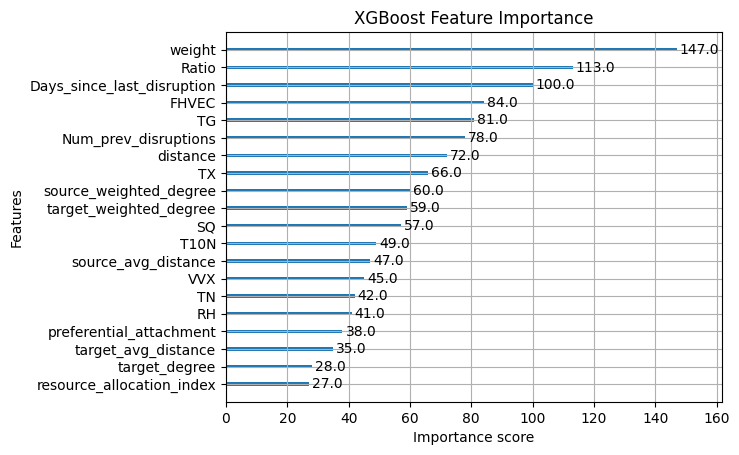

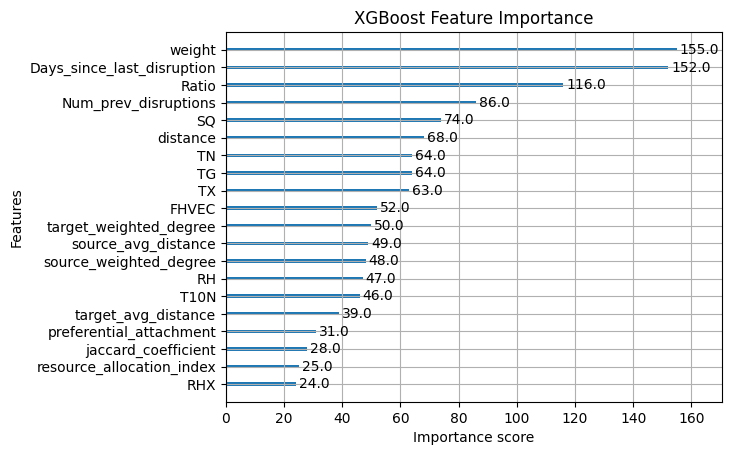

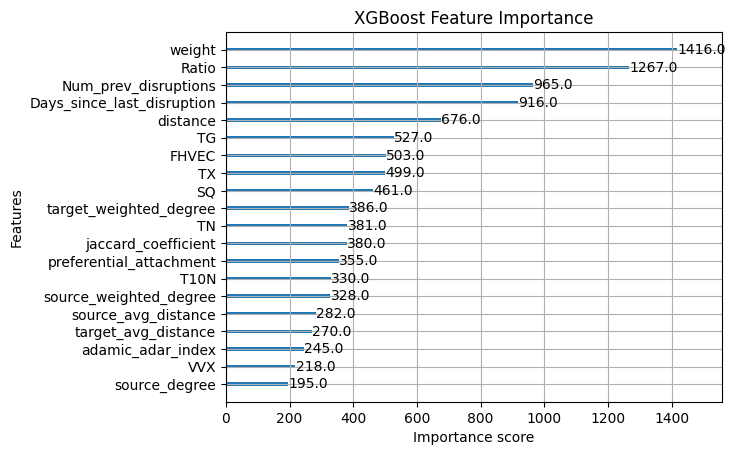

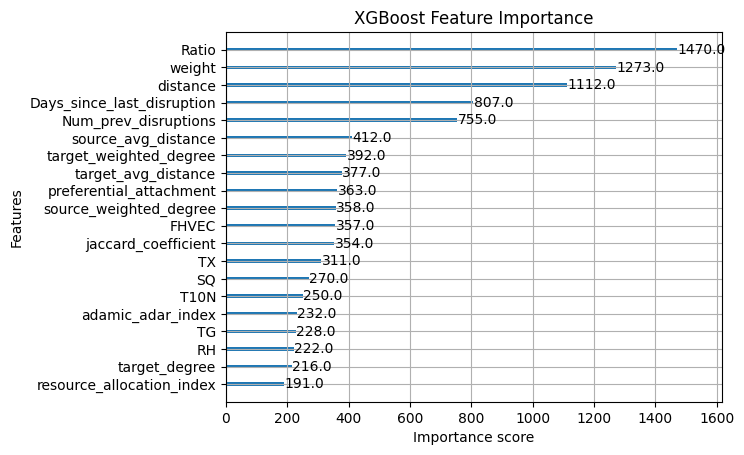

In [46]:
xgb_models = {}
xgb_params = {}
xgb_features = {}

for season in seasons:
    X = seasonal_splits[season]
    xgb_models[season], xgb_params[season] = optimise(xgb, scoring, param_grid_xgb, X, season)

[0.01587207 0.05722214 0.02732864 0.03013584 0.07234612 0.02667364
 0.00257322 0.01298437 0.02339405 0.01343946 0.0532453  0.92110443
 0.08837661 0.14218959 0.19124806 0.10065752 0.06328323 0.1067756
 0.06947682 0.03709951 0.03259752 0.03670534 0.3574758  0.12095893
 0.24051936]


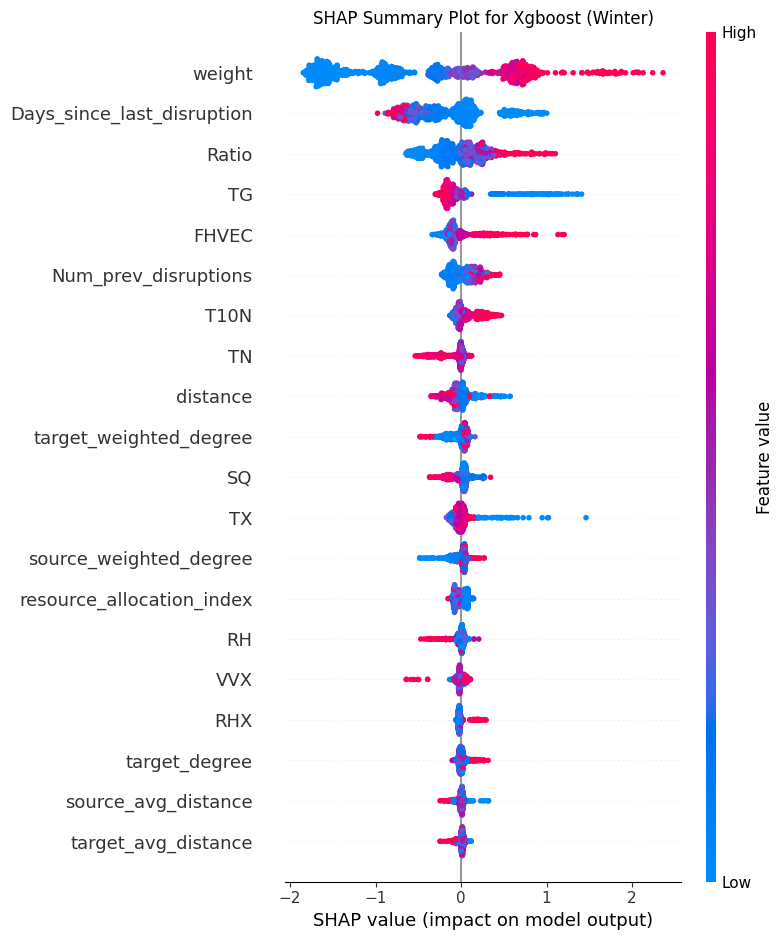

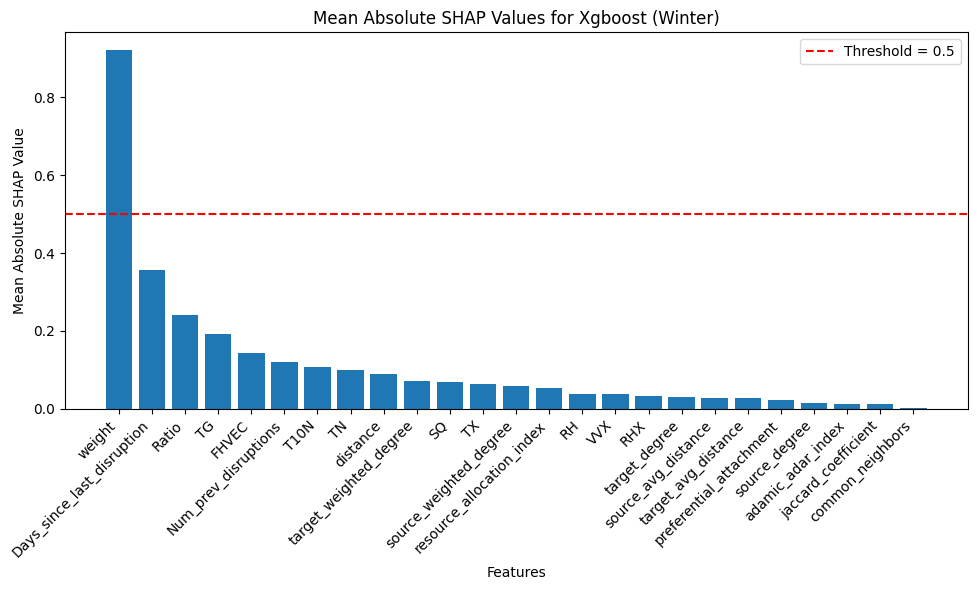

[0.034671   0.10739353 0.04918552 0.02107329 0.09470273 0.02746661
 0.00722545 0.01882432 0.02014149 0.00686733 0.02388165 0.796537
 0.07269453 0.07314788 0.05286417 0.06902149 0.11621112 0.0470239
 0.09561831 0.05256333 0.01512154 0.03959522 0.81354123 0.08753992
 0.28883132]


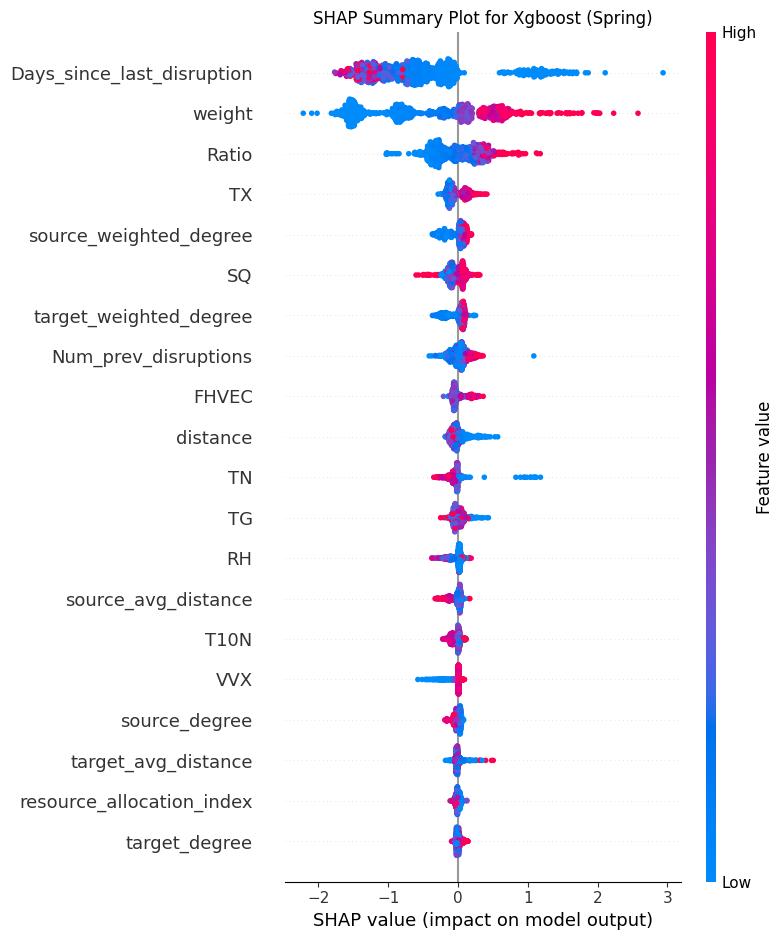

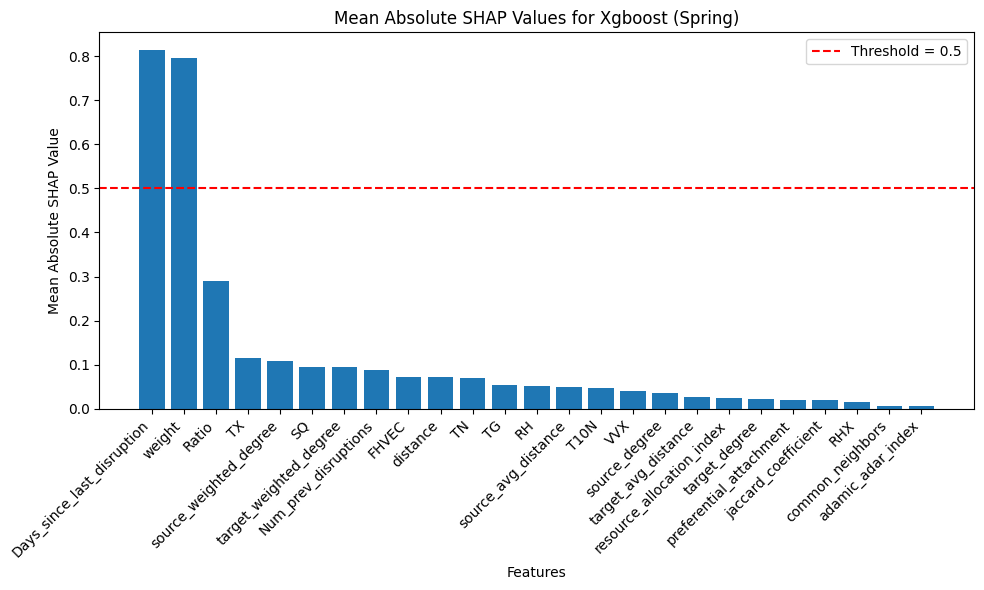

[0.00190715 0.00532435 0.00431096 0.00211725 0.00974948 0.00456524
 0.00070633 0.0062695  0.00360468 0.00557373 0.0024031  0.48242044
 0.03246689 0.00999701 0.00862611 0.00688639 0.01144051 0.00629125
 0.00772339 0.00160122 0.00253603 0.01215724 0.22538202 0.11485977
 0.09211425]


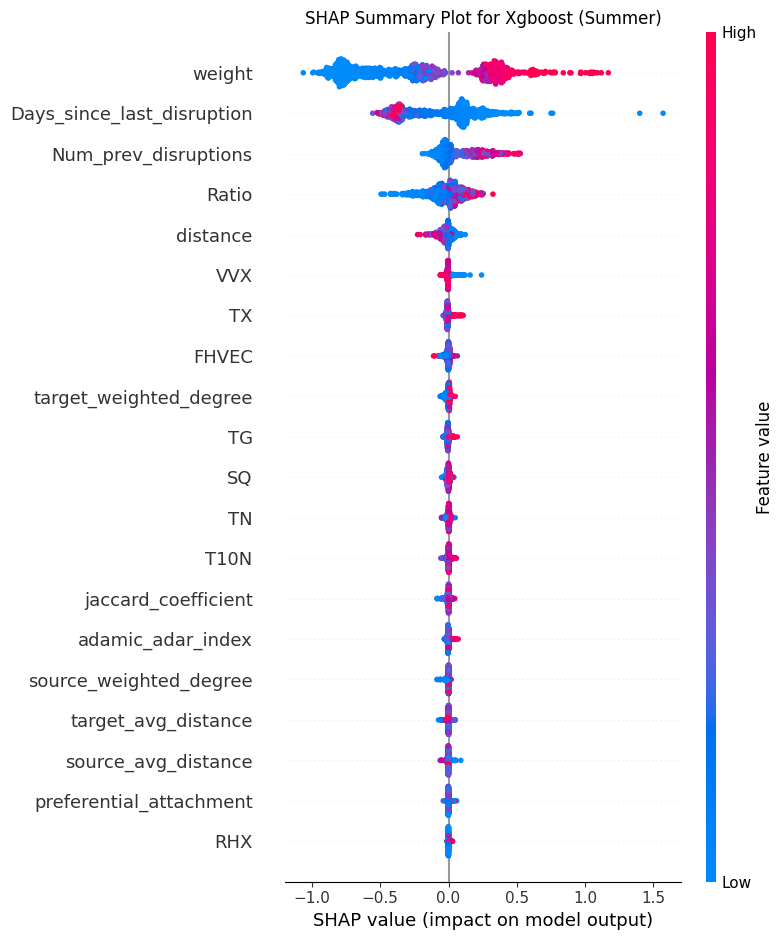

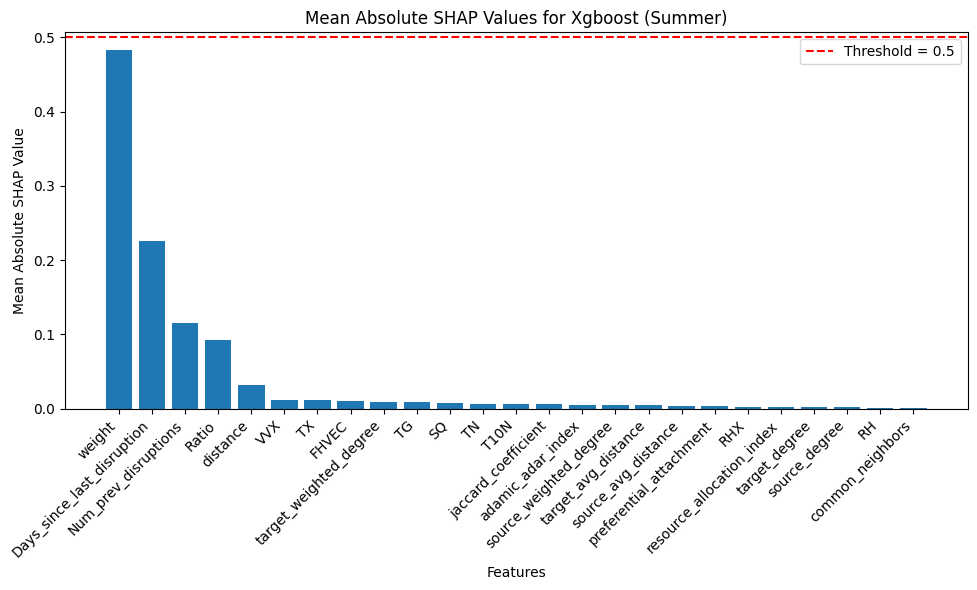

[0.00273563 0.01173116 0.00515675 0.00469045 0.00952547 0.00710458
 0.00119216 0.00409424 0.00928165 0.00500164 0.0037102  0.5914183
 0.04822822 0.00398069 0.00298395 0.00240616 0.00328448 0.0039859
 0.00160252 0.00284375 0.00119693 0.00209226 0.14575274 0.06327262
 0.1431277 ]


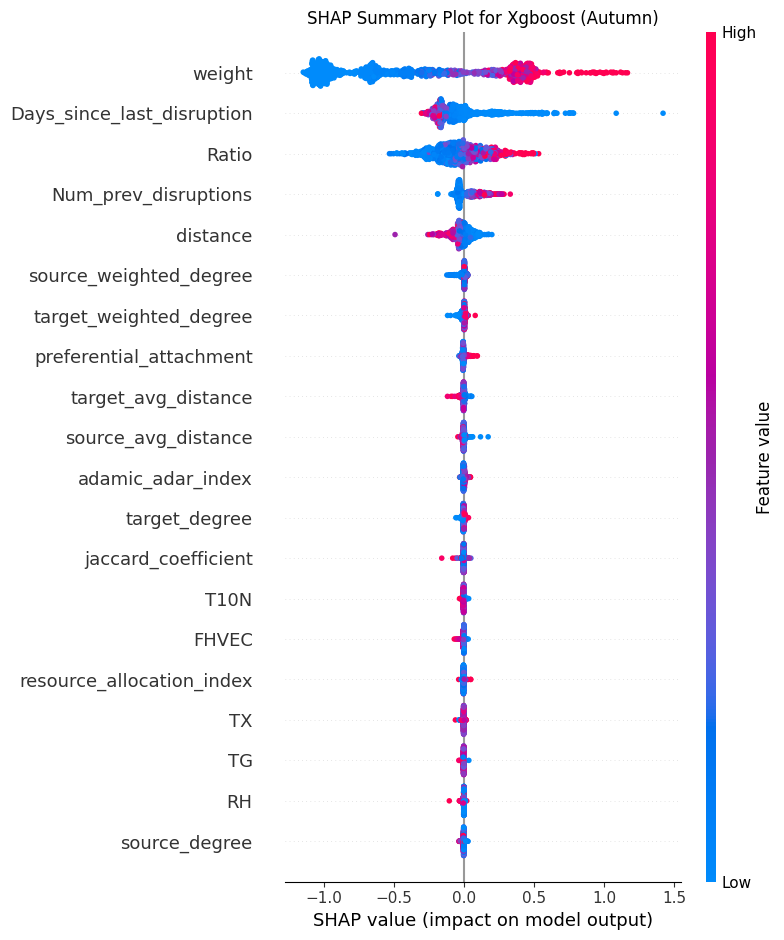

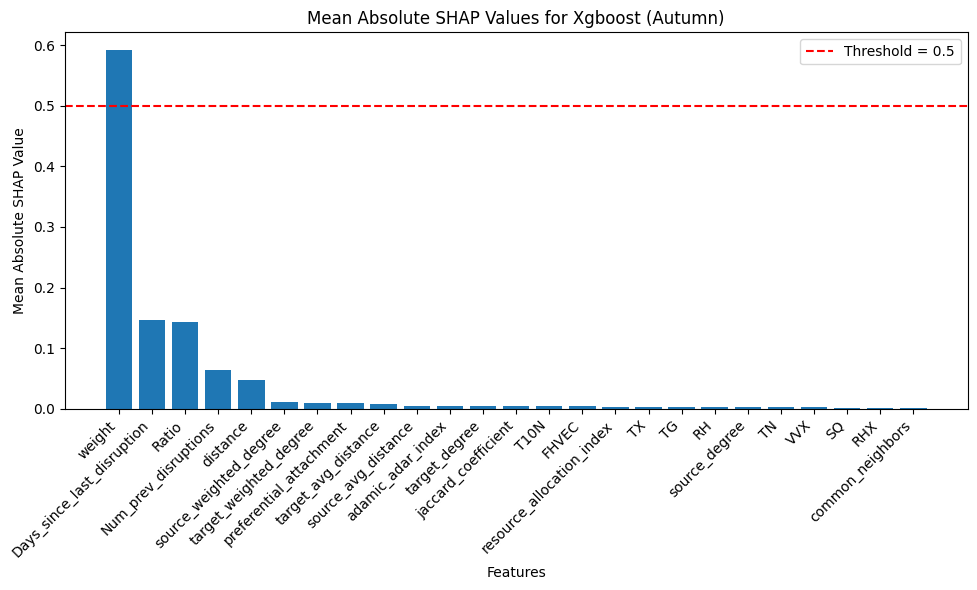

In [47]:
for season in seasons:
    X = seasonal_splits[season]
    val_data = split_season_by_year(X, season)
    val_data = val_data[f'{season} 2023']
    feature_cols = topo_features + wthr_features + oper_features
    shap_values = plot_shap_values(xgb_models[season], val_data[feature_cols], feature_cols, model_type='xgboost', season=season)

In [48]:
from shap_select import shap_select	
feature_selection_xgb = {}
for season in seasons:
    X = seasonal_splits[season]
    val_data = split_season_by_year(X, season)
    val_data = val_data[f'{season} 2023']
    feature_cols = topo_features + wthr_features + oper_features
    selected_features_df = shap_select(xgb_models[season], val_data[feature_cols], val_data['Disrupted'], task="binary", threshold=0.05)
    print(f"Selected features for {season}:")
    print(selected_features_df)
    selected_features_df = selected_features_df[selected_features_df['selected'] == 1]
    sel_feat_list = selected_features_df['feature name'].tolist()
    feature_selection_xgb[season] = sel_feat_list
    print(sel_feat_list)

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Winter:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  40.395716       0.000000e+00     1.095700   
1                        Ratio  27.401802      2.610257e-165     2.167350   
2   Days_since_last_disruption  19.559796       3.404345e-85     1.217400   
3         Num_prev_disruptions   7.257241       3.950666e-13     1.256147   
4                           TG   5.235788       1.642824e-07     0.421598   
5                     distance   3.703545       2.126076e-04     0.916134   
6       source_weighted_degree   3.427204       6.098316e-04     1.306788   
7                source_degree   2.838776       4.528699e-03     2.654966   
8          target_avg_distance   2.663265       7.738651e-03     1.731908   
9                target_degree   2.525899       1.154028e-02     1.218463   
10                          TN   2.063614       3.905432e-02     0.682252   
11     preferential_attachment   1.739561     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Spring:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  41.722774       0.000000e+00     1.250005   
1   Days_since_last_disruption  26.529026      4.484569e-155     0.740734   
2                        Ratio  17.747068       1.815896e-70     1.243854   
3                           TX   9.242519       2.407615e-20     1.553079   
4         Num_prev_disruptions   8.207170       2.264633e-16     1.555528   
5                     distance   4.839348       1.302656e-06     1.080242   
6       source_weighted_degree   4.763766       1.900133e-06     0.918173   
7       target_weighted_degree   4.602053       4.183459e-06     0.980175   
8          source_avg_distance   3.366724       7.606678e-04     1.304528   
9                           TG   2.136538       3.263562e-02     0.778658   
10   resource_allocation_index   1.379048       1.678801e-01     1.444613   
11               target_degree   1.353201     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Summer:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  42.973936       0.000000e+00     2.193002   
1   Days_since_last_disruption  23.704905      3.209279e-124     2.591866   
2                        Ratio  11.451142       2.320676e-30     2.149149   
3         Num_prev_disruptions   6.046724       1.478210e-09     1.007160   
4                     distance   4.657485       3.200960e-06     3.061572   
5       target_weighted_degree   3.969542       7.201089e-05     7.280301   
6                           TX   3.910988       9.191936e-05     4.547412   
7            adamic_adar_index   2.690267       7.139493e-03     7.303974   
8                          RHX   2.617741       8.851392e-03    17.553932   
9      preferential_attachment   2.090025       3.661552e-02     8.319607   
10                         VVX   1.885351       5.938249e-02     2.156248   
11      source_weighted_degree   1.073121     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Autumn:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  41.484594       0.000000e+00     1.795300   
1   Days_since_last_disruption  23.376211      7.462091e-121     2.571051   
2                        Ratio  15.166486       5.894926e-52     1.889768   
3         Num_prev_disruptions   7.337282       2.179757e-13     2.261638   
4                     distance   6.535602       6.335419e-11     2.848221   
5                target_degree   4.588809       4.457821e-06    19.166304   
6       source_weighted_degree   4.533402       5.804118e-06     5.719646   
7          source_avg_distance   2.495496       1.257813e-02     4.760561   
8      preferential_attachment   2.200004       2.780664e-02     3.156727   
9                          VVX   1.154442       2.483188e-01     7.030193   
10      target_weighted_degree   0.389750       6.967211e-01     0.750971   
11   resource_allocation_index   0.325978     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 2 out of 2 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


In [50]:
xgb_models_selected = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    train_data = pd.concat([test_data[year] for year in test_data if year != f'{season} 2024'])
    test_data = test_data[f'{season} 2024']
    
    # Extract selected features
    selected_features = feature_selection_xgb[season]
    
    # Prepare training and testing data
    X_train = train_data[selected_features]
    y_train = train_data['Disrupted'].astype(int)
    X_test = test_data[selected_features]
    y_test = test_data['Disrupted'].astype(int)
    
    # Train the XGBoost model
    model = XGBClassifier(random_state=42, **xgb_params[season])
    model.fit(X_train, y_train)
    
    # Store the trained model
    xgb_models_selected[season] = model
    
    # Evaluate the model
    y_pred = model.predict(X_test)
    print(f"Season: {season}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

Season: Winter
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      2651
           1       0.18      0.73      0.30       210

    accuracy                           0.74      2861
   macro avg       0.58      0.74      0.57      2861
weighted avg       0.91      0.74      0.80      2861

Accuracy: 0.7431
F1 Score: 0.2953
Precision: 0.1849
Recall: 0.7333
Balanced Accuracy: 0.7386
AUC: 0.8265
Season: Spring
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     17463
           1       0.24      0.74      0.36      1984

    accuracy                           0.74     19447
   macro avg       0.60      0.74      0.60     19447
weighted avg       0.89      0.74      0.79     19447

Accuracy: 0.7353
F1 Score: 0.3637
Precision: 0.2410
Recall: 0.7414
Balanced Accuracy: 0.7380
AUC: 0.8147
Season: Summer
Classification Report:
              precisio

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best F1 Score: 0.3964950368864975
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     16755
           1       0.29      0.75      0.42      2335

    accuracy                           0.75     19090
   macro avg       0.62      0.75      0.63     19090
weighted avg       0.87      0.75      0.79     19090

Accuracy: 0.7455
F1 Score: 0.4197
Precision: 0.2910
Recall: 0.7525
Balanced Accuracy: 0.7485
AUC: 0.8241


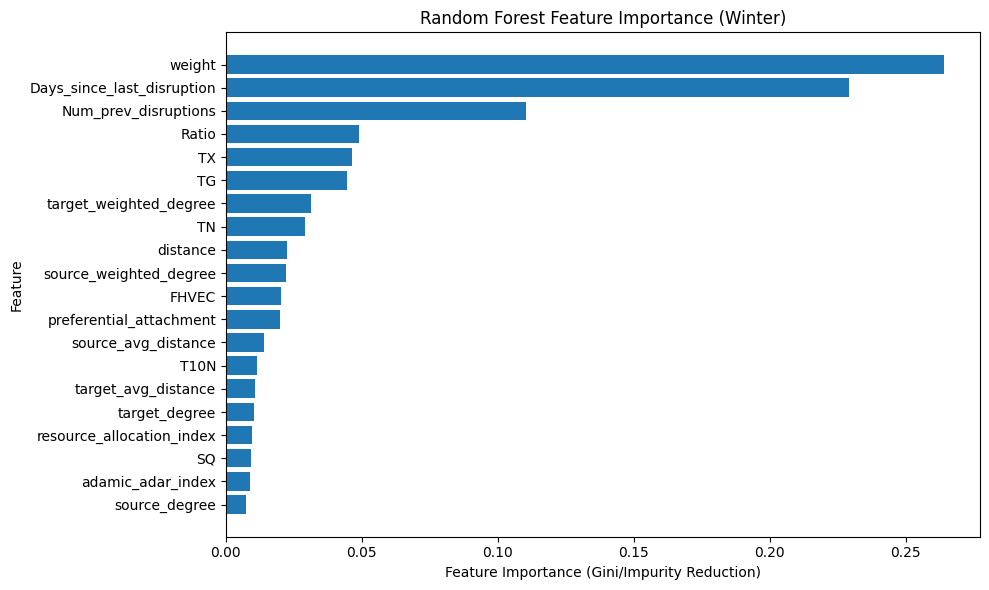

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best F1 Score: 0.4790220615105766
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.87     16987
           1       0.35      0.64      0.45      2604

    accuracy                           0.79     19591
   macro avg       0.64      0.73      0.66     19591
weighted avg       0.86      0.79      0.82     19591

Accuracy: 0.7937
F1 Score: 0.4501
Precision: 0.3486
Recall: 0.6352
Balanced Accuracy: 0.7266
AUC: 0.8152


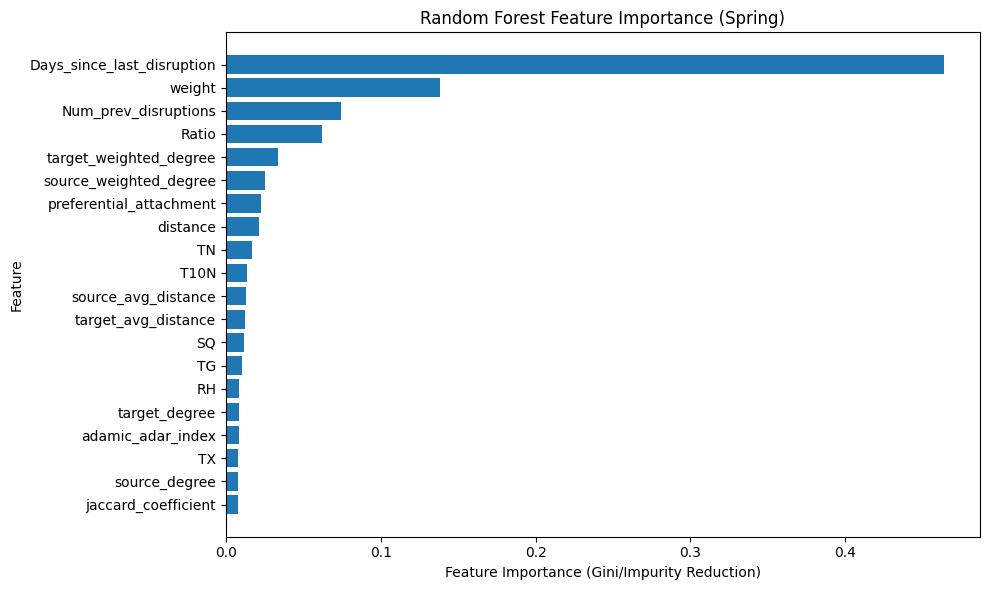

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best F1 Score: 0.4291420549781349
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     16774
           1       0.30      0.74      0.42      2483

    accuracy                           0.74     19257
   macro avg       0.62      0.74      0.63     19257
weighted avg       0.87      0.74      0.78     19257

Accuracy: 0.7419
F1 Score: 0.4235
Precision: 0.2974
Recall: 0.7354
Balanced Accuracy: 0.7391
AUC: 0.8153


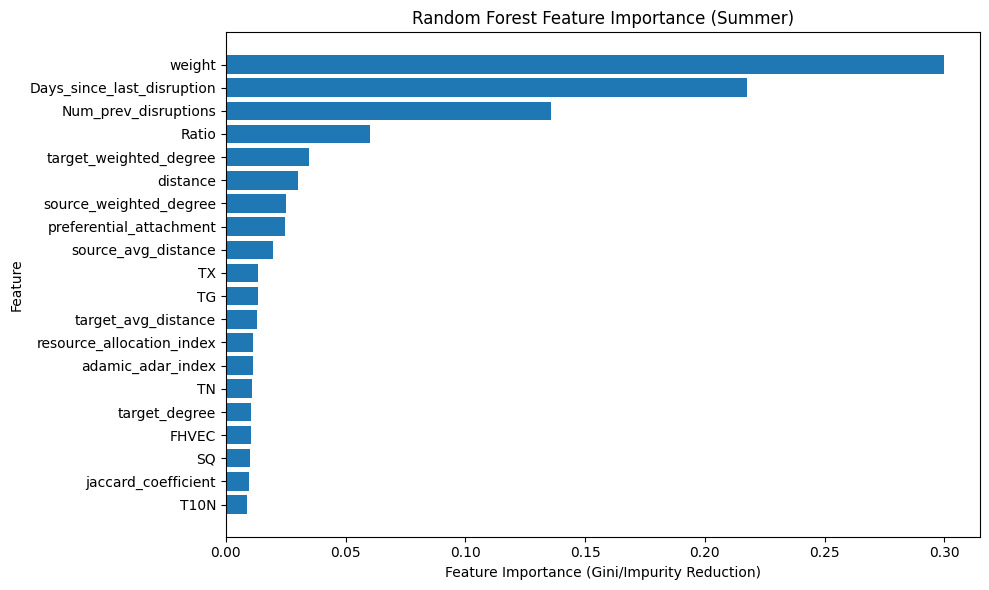

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best F1 Score: 0.4358793288069712
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     16645
           1       0.29      0.74      0.42      2592

    accuracy                           0.72     19237
   macro avg       0.62      0.73      0.62     19237
weighted avg       0.86      0.72      0.77     19237

Accuracy: 0.7247
F1 Score: 0.4207
Precision: 0.2936
Recall: 0.7419
Balanced Accuracy: 0.7320
AUC: 0.8079


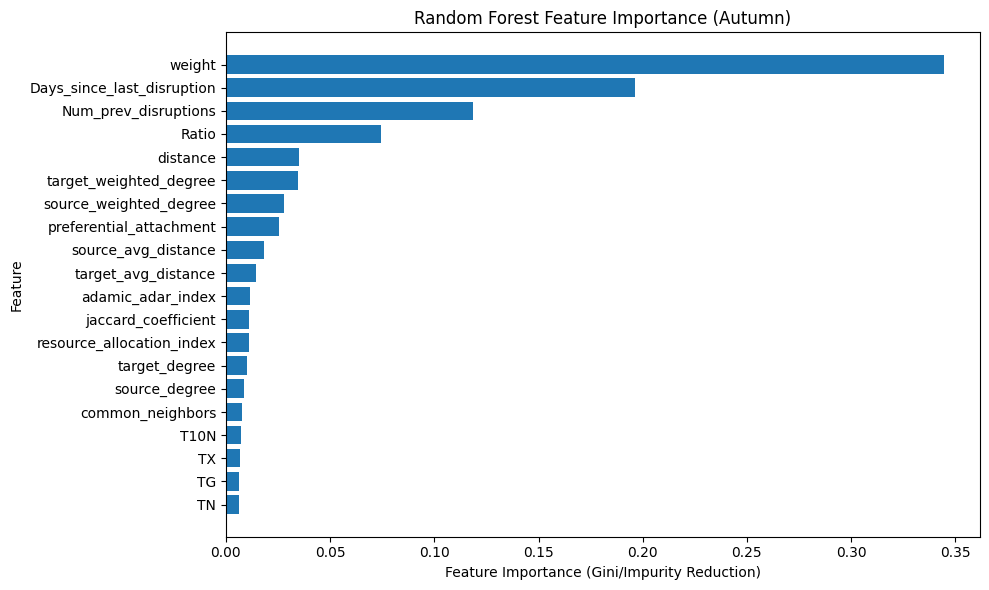

In [52]:
rf_models = {}
rf_params = {}
rf_features = {}

for season in seasons:
    X = seasonal_splits[season]
    rf_models[season], rf_params[season] = optimise(rf, scoring, param_grid_rf, X, season)

[0.00150432 0.01166566 0.00483951 0.00284132 0.02066743 0.00290953
 0.00122673 0.00172712 0.00534572 0.0020046  0.0033486  0.11357023
 0.01096282 0.01163607 0.01137743 0.00604888 0.01214723 0.00348216
 0.00258615 0.00200362 0.00172378 0.00144879 0.07823454 0.04310414
 0.01685665]


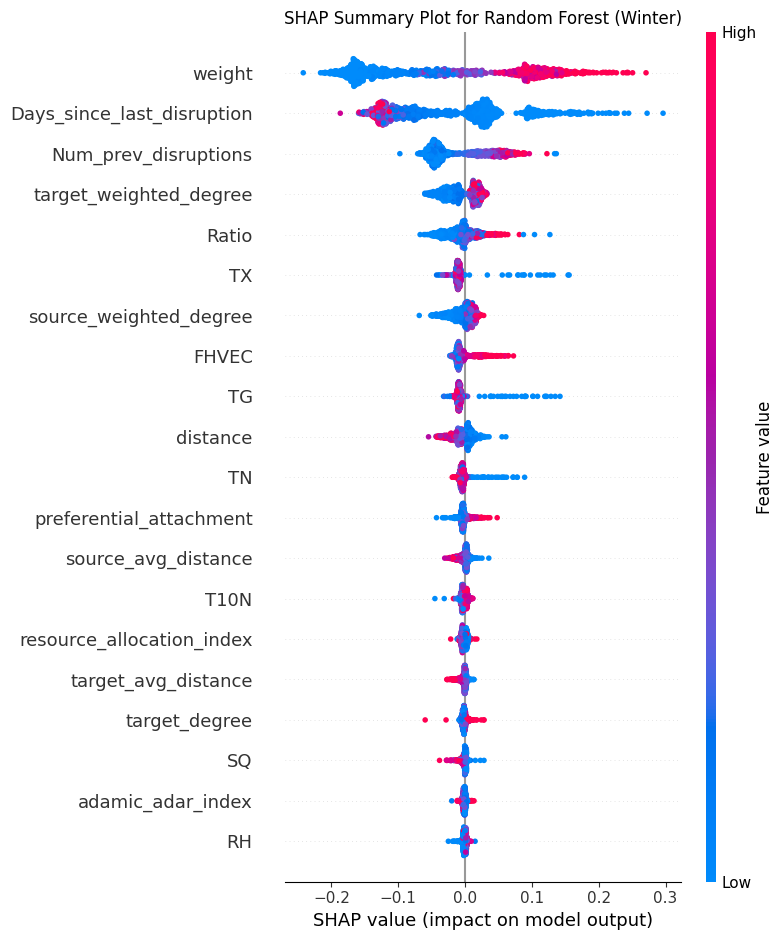

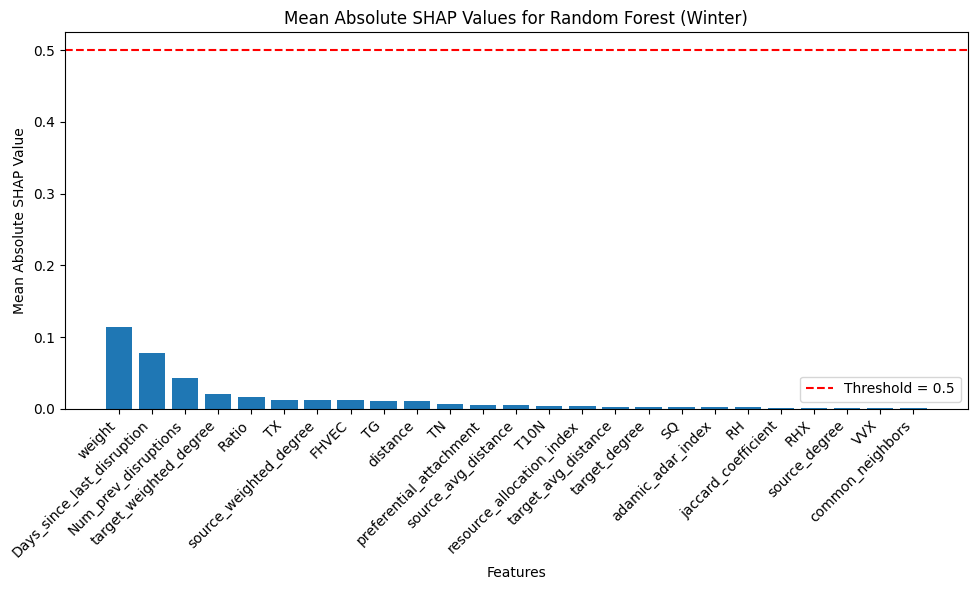

[0.00177282 0.01740481 0.00585    0.00356733 0.02306745 0.00528726
 0.00146459 0.00224421 0.00875171 0.00189123 0.00202094 0.08689328
 0.01106593 0.00208649 0.00363126 0.00675986 0.00346668 0.00561717
 0.00678827 0.00584894 0.00337747 0.00310725 0.14261666 0.0333021
 0.02886134]


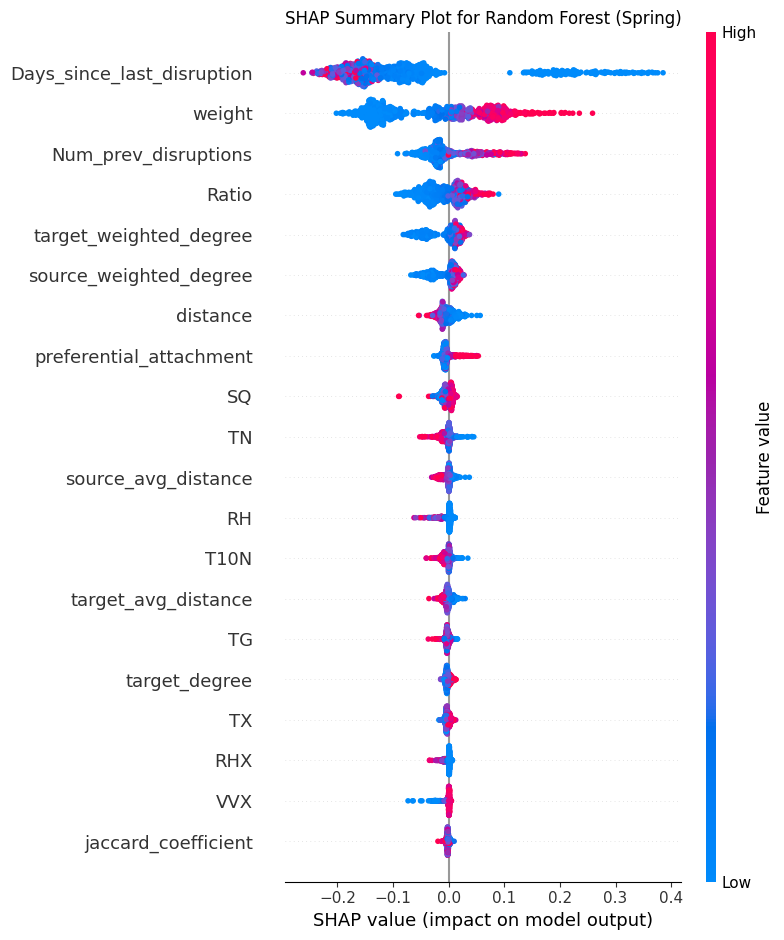

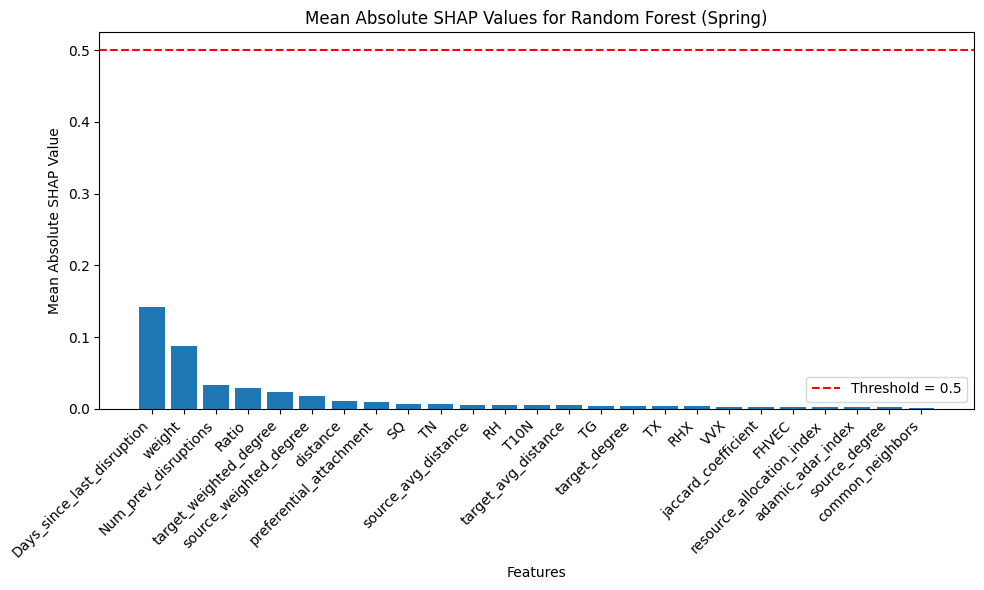

[0.00180048 0.01093738 0.00726727 0.00268871 0.01905207 0.00360779
 0.00160313 0.002797   0.00670407 0.00281223 0.00287646 0.13062694
 0.01687737 0.00314972 0.00413347 0.00283867 0.00433255 0.00224635
 0.00275043 0.00126107 0.00117825 0.0022286  0.08173925 0.05012489
 0.01573622]


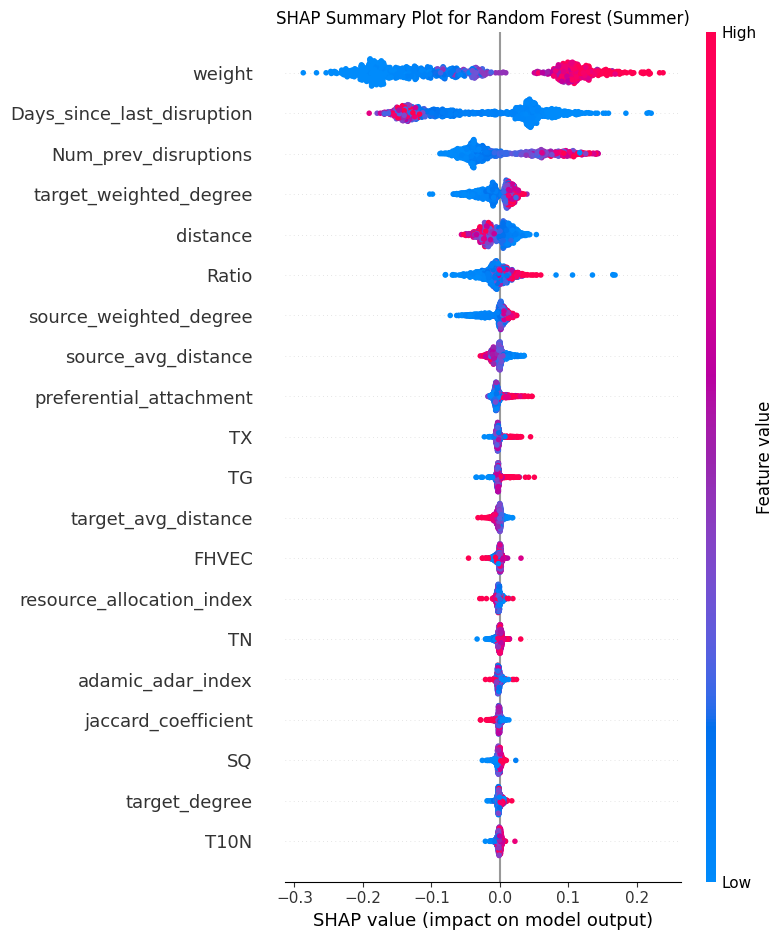

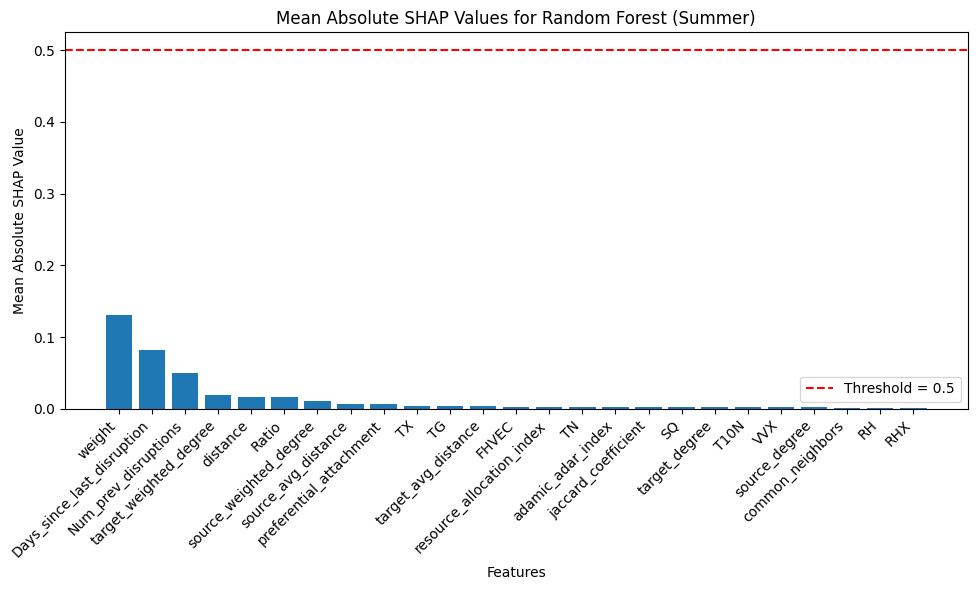

[0.00189135 0.01430796 0.00711337 0.002633   0.02095848 0.00507065
 0.00201898 0.0037962  0.00586754 0.00278687 0.00260196 0.15062379
 0.01998175 0.00136633 0.00151667 0.00155942 0.00155176 0.00186019
 0.00103733 0.00107328 0.00088023 0.00095168 0.06257818 0.04438797
 0.02186511]


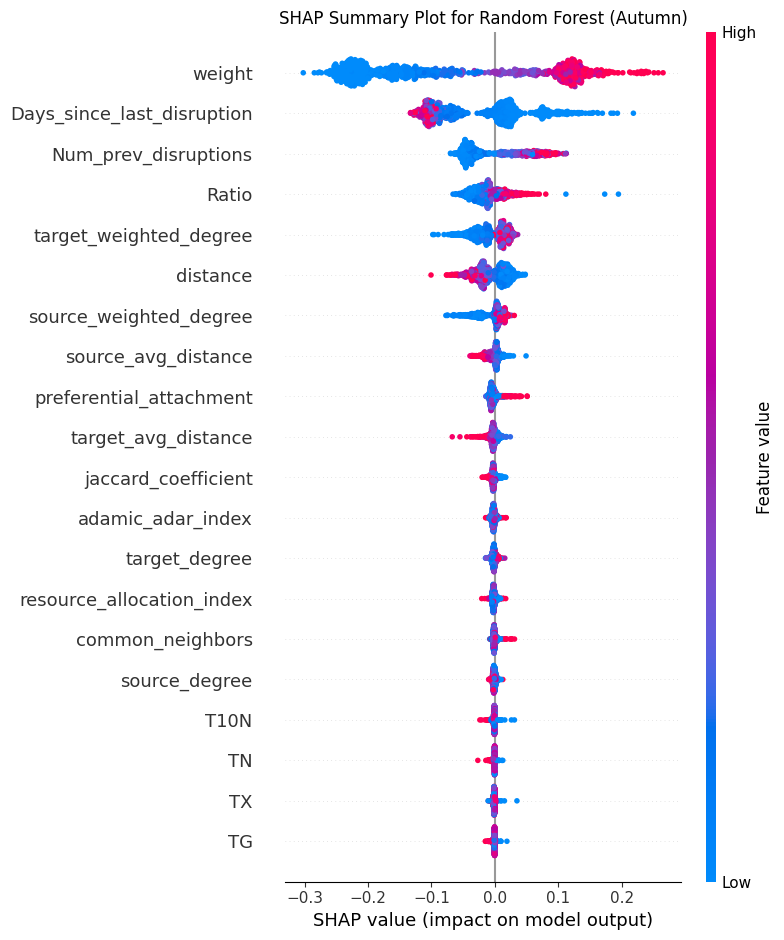

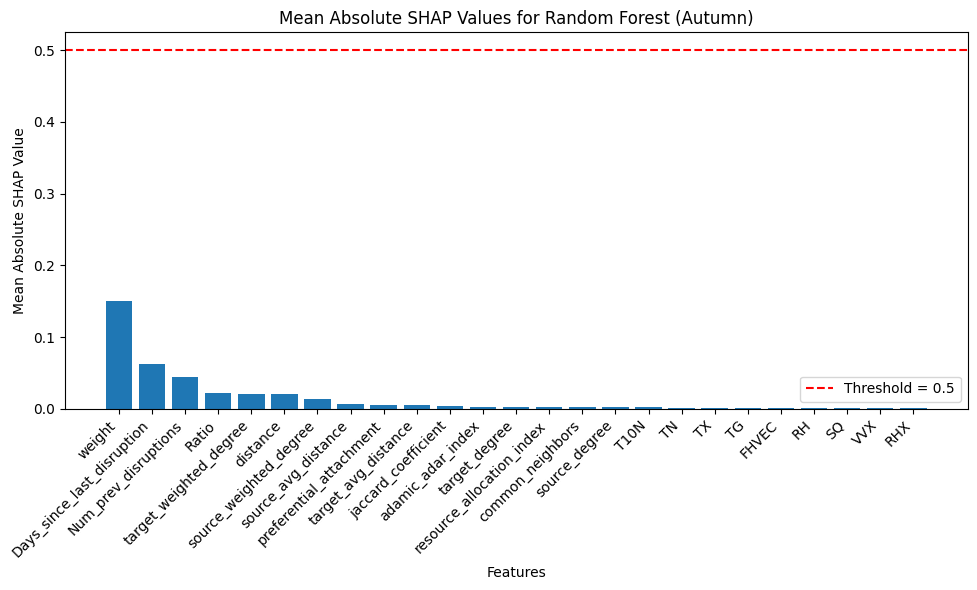

In [53]:
rf_shap_values = {}
for season in seasons:
    X = seasonal_splits[season]
    val_data = split_season_by_year(X, season)
    val_data[f'{season} 2023']
    feature_cols = topo_features + wthr_features + oper_features
    shap_values = plot_shap_values(rf_models[season], X[feature_cols], feature_cols, model_type='random_forest', season=season)
    rf_shap_values[season] = shap_values

In [54]:
rf_top_features = {}

for season in seasons:
    shap_values = rf_shap_values[season]
    mean_shap_values = np.abs(shap_values).mean(axis=0)
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': mean_shap_values
    }).sort_values(by='Importance', ascending=False)
    
    rf_top_features[season] = feature_importance['Feature'].head(10).tolist()

print(rf_top_features)

{'Winter': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'target_weighted_degree', 'Ratio', 'TX', 'source_weighted_degree', 'FHVEC', 'TG', 'distance'], 'Spring': ['Days_since_last_disruption', 'weight', 'Num_prev_disruptions', 'Ratio', 'target_weighted_degree', 'source_weighted_degree', 'distance', 'preferential_attachment', 'SQ', 'TN'], 'Summer': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'target_weighted_degree', 'distance', 'Ratio', 'source_weighted_degree', 'source_avg_distance', 'preferential_attachment', 'TX'], 'Autumn': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'Ratio', 'target_weighted_degree', 'distance', 'source_weighted_degree', 'source_avg_distance', 'preferential_attachment', 'target_avg_distance']}


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.3}
Best F1 Score: 0.3386626513126552
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     16755
           1       0.31      0.41      0.36      2335

    accuracy                           0.82     19090
   macro avg       0.61      0.64      0.63     19090
weighted avg       0.84      0.82      0.83     19090

Accuracy: 0.8186
F1 Score: 0.3558
Precision: 0.3146
Recall: 0.4094
Balanced Accuracy: 0.6426
AUC: 0.7673


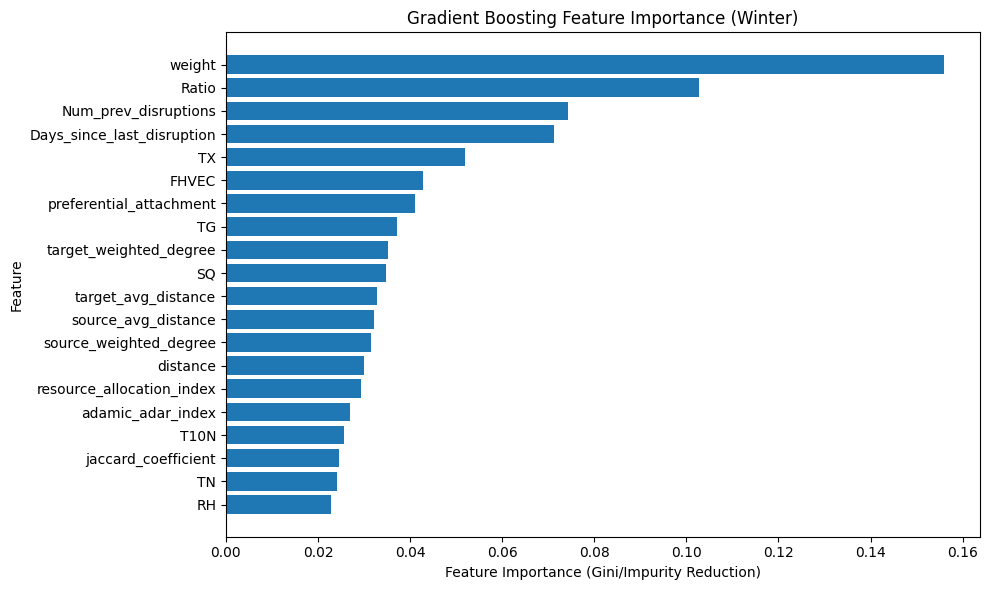

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}
Best F1 Score: 0.3861610709227727
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     16987
           1       0.42      0.37      0.39      2604

    accuracy                           0.85     19591
   macro avg       0.66      0.65      0.65     19591
weighted avg       0.84      0.85      0.84     19591

Accuracy: 0.8482
F1 Score: 0.3939
Precision: 0.4198
Recall: 0.3710
Balanced Accuracy: 0.6462
AUC: 0.7976


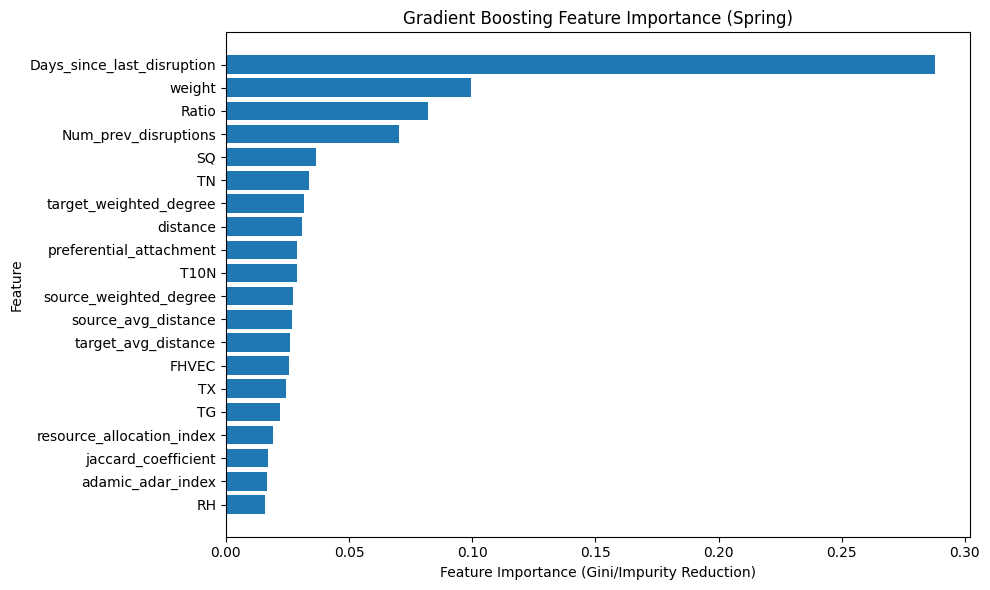

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.3}
Best F1 Score: 0.3112466884770651
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     16774
           1       0.34      0.34      0.34      2483

    accuracy                           0.83     19257
   macro avg       0.62      0.62      0.62     19257
weighted avg       0.83      0.83      0.83     19257

Accuracy: 0.8289
F1 Score: 0.3382
Precision: 0.3373
Recall: 0.3391
Balanced Accuracy: 0.6203
AUC: 0.7698


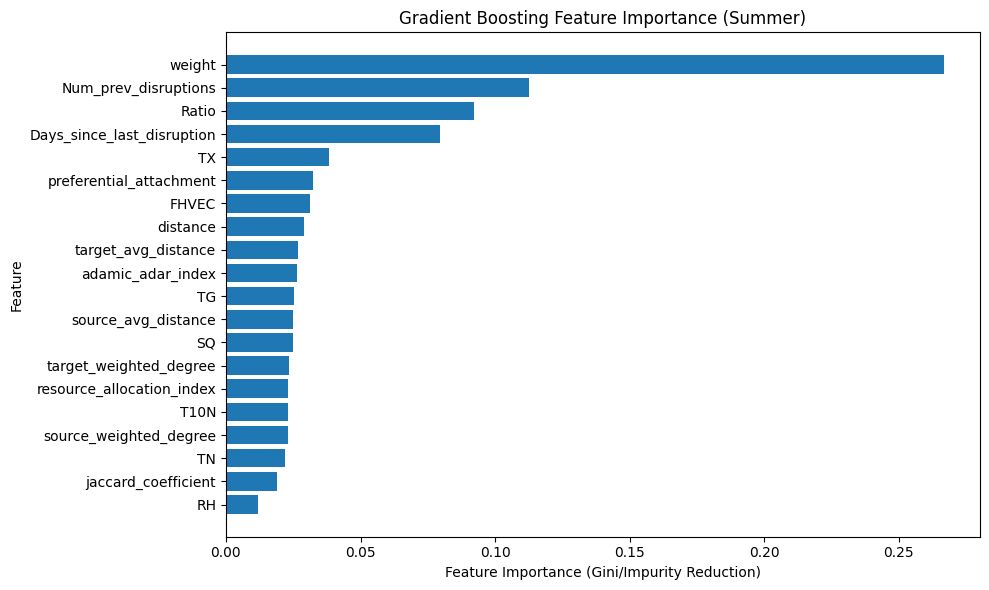

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.3}
Best F1 Score: 0.326357105240903
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     16645
           1       0.34      0.24      0.28      2592

    accuracy                           0.83     19237
   macro avg       0.61      0.58      0.59     19237
weighted avg       0.81      0.83      0.82     19237

Accuracy: 0.8335
F1 Score: 0.2792
Precision: 0.3351
Recall: 0.2392
Balanced Accuracy: 0.5827
AUC: 0.7570


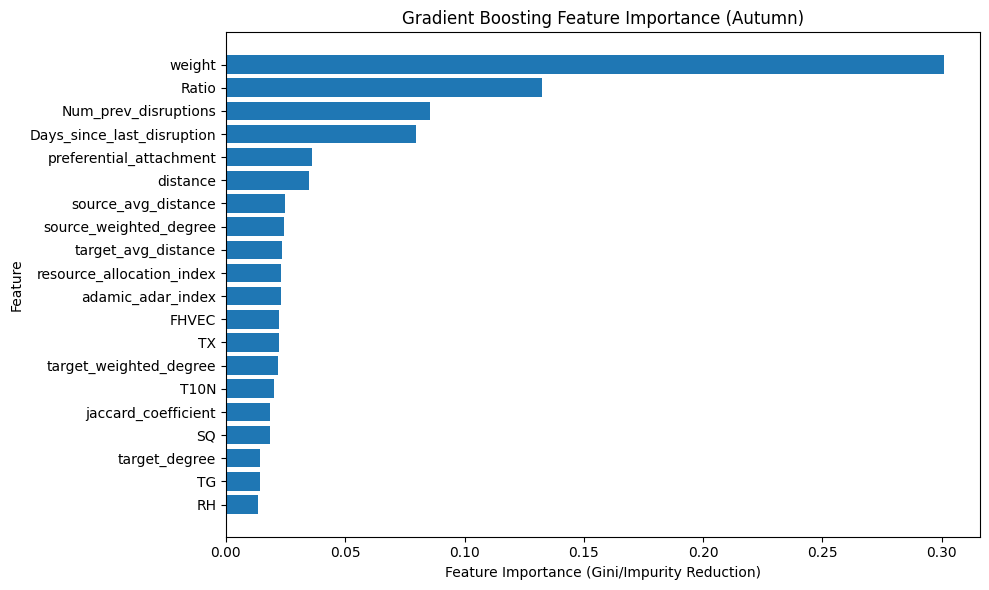

In [55]:
gb_models = {}
gb_params = {}
gb_features = {}

for season in seasons:
    X = seasonal_splits[season]
    gb_models[season], gb_params[season] = optimise(gbdt, scoring, param_grid_gbdt, X, season)

[2.19200542e+02 2.03942601e+03 3.14451263e+00 1.62761855e-01
 2.35877374e+03 1.66399159e-01 2.05354217e-01 9.82257245e+02
 9.19482940e+02 1.01869134e+02 2.39978410e+03 1.27887593e+01
 2.27266109e+02 7.26595971e+00 3.31323831e-01 2.37125242e-01
 3.17671109e-01 2.89552176e+02 2.85190970e-01 7.91010926e-01
 8.62679105e+02 1.71784948e-01 1.97806215e+03 2.75427652e+02
 5.30357305e-01]


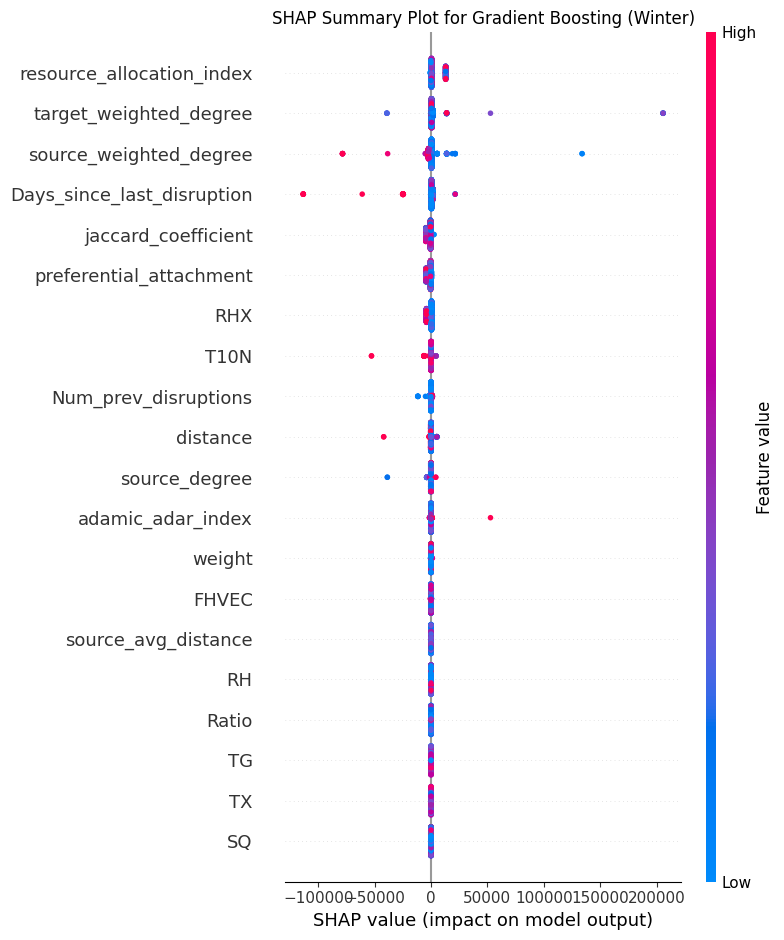

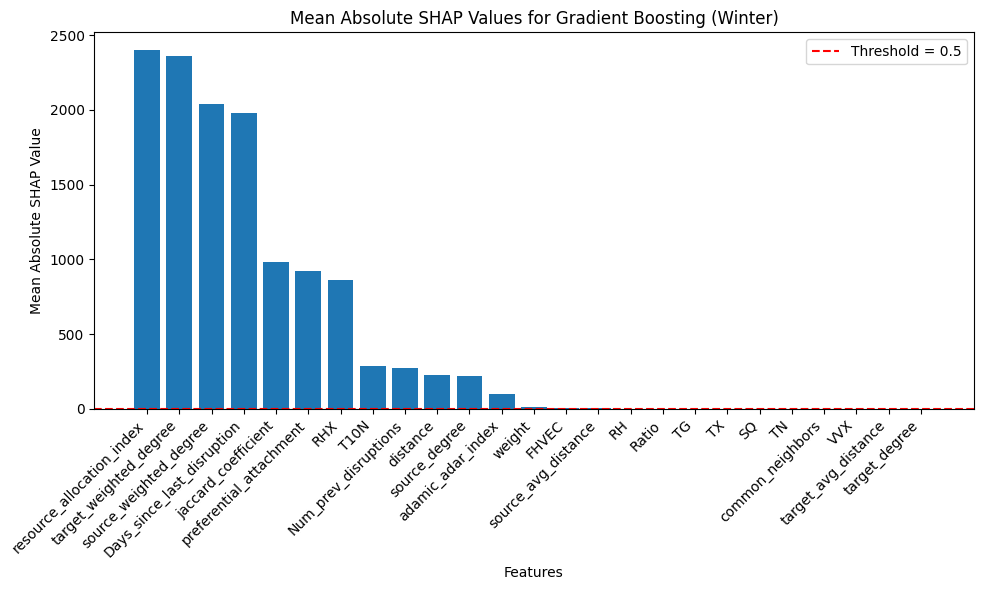

[0.06629848 0.1444858  0.0957307  0.0693544  0.16105333 0.16600091
 0.00860765 0.07624161 0.08018366 0.16295662 0.14569139 0.95026824
 0.11339076 0.10573324 0.12509405 0.10303518 0.12206037 0.10016348
 0.08406331 0.05139241 0.0357062  0.04738776 0.60239382 0.27128789
 0.29478583]


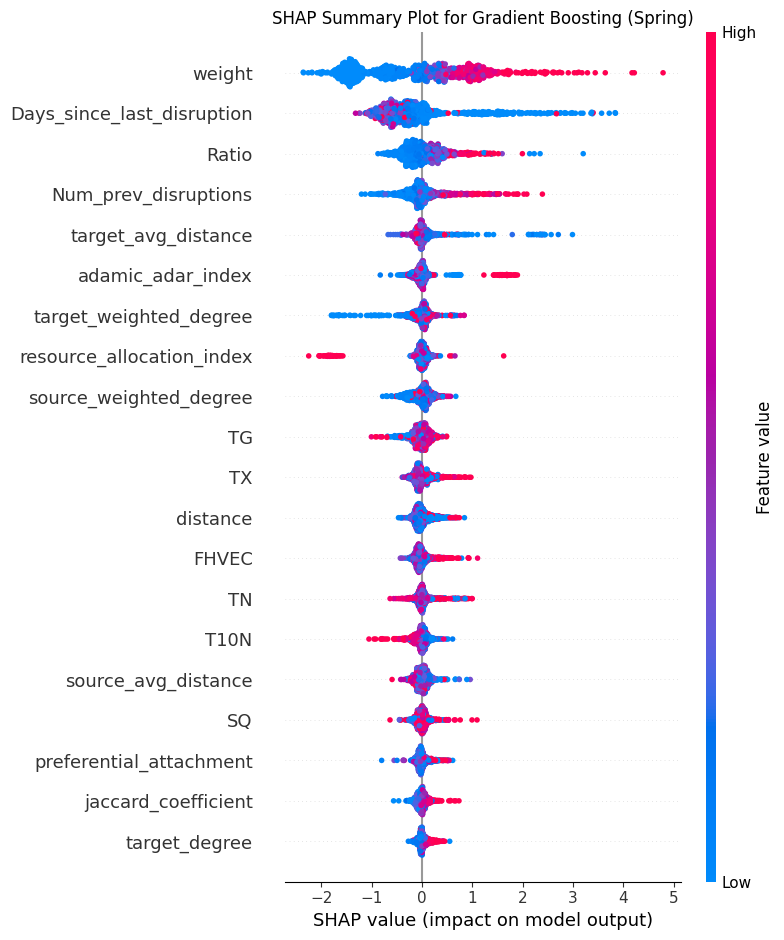

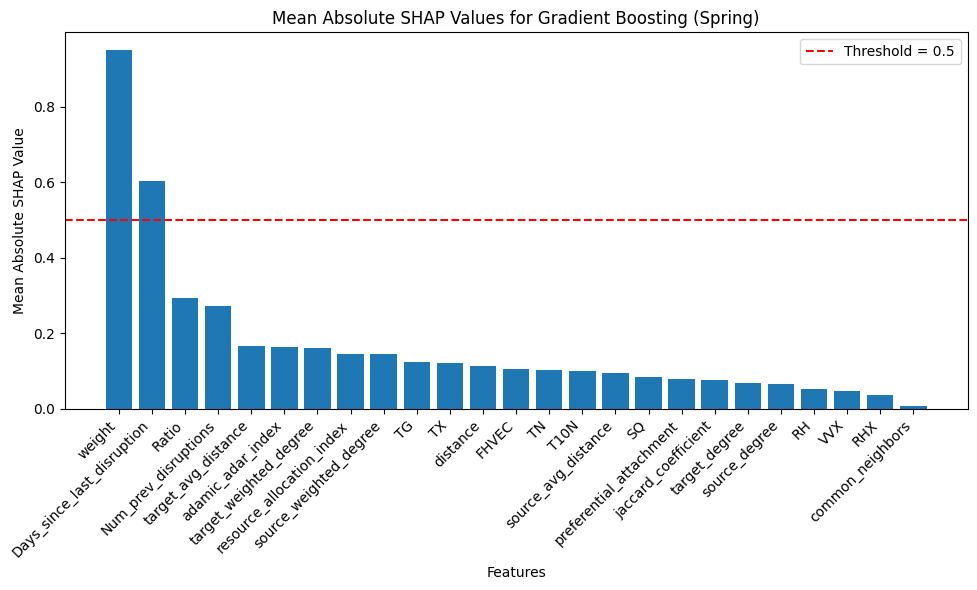

[7.68698988e-02 1.48800248e-01 1.20659402e-01 8.92014370e-02
 1.40832878e-01 1.34770150e-01 2.58543436e-02 2.24198642e-01
 6.51718050e+02 3.23004027e-01 2.81496602e-01 1.10233697e+00
 6.46532402e+02 1.19234784e-01 1.44496691e-01 1.40344249e-01
 1.21152679e-01 1.07817329e-01 1.56490096e-01 5.74607863e+00
 9.98887598e-02 7.13950780e-02 3.94490594e-01 4.81079079e-01
 2.95379295e-01]


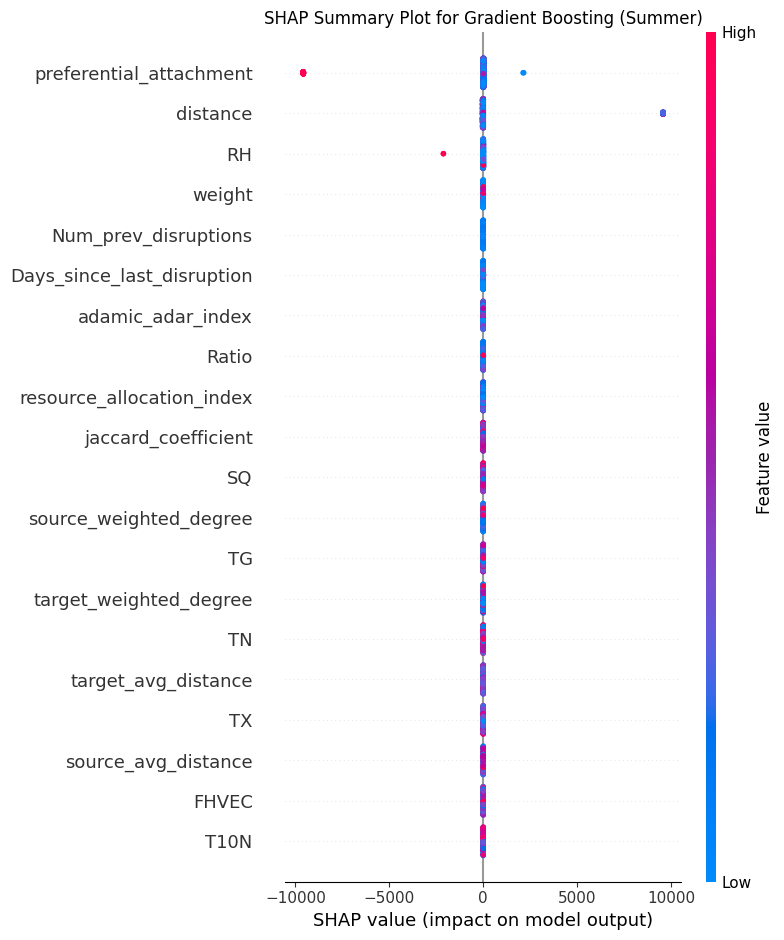

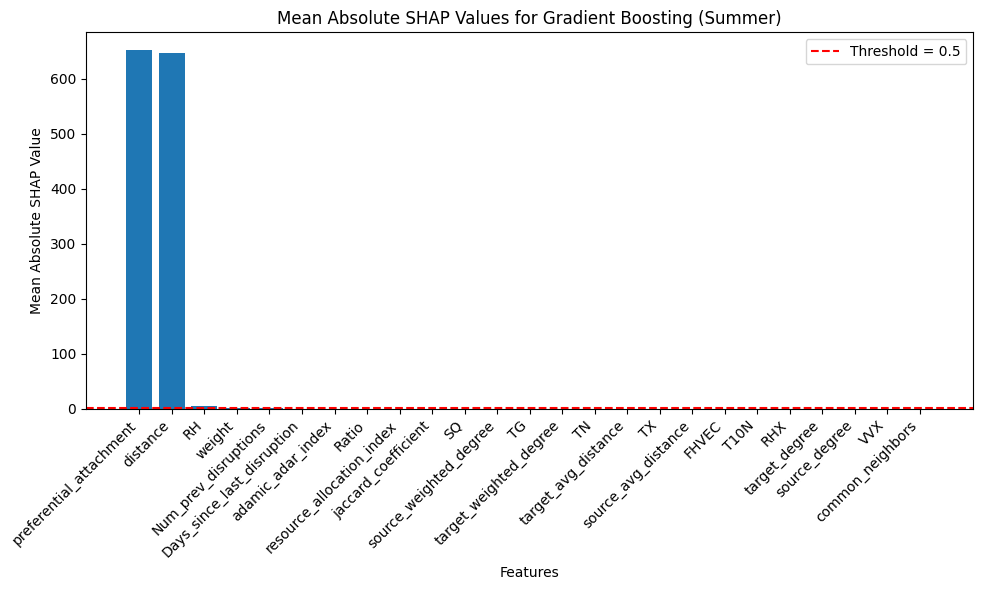

[0.11829929 0.20582281 0.08712862 0.07170487 0.14765409 0.1097543
 0.03912005 0.12872506 0.17715351 0.18105645 0.18935216 1.30750723
 0.26571933 0.0754029  0.15828898 0.14740438 0.1384088  0.15921359
 0.11689276 0.09576504 0.06957026 0.08273678 0.30893512 0.25479562
 0.40687154]


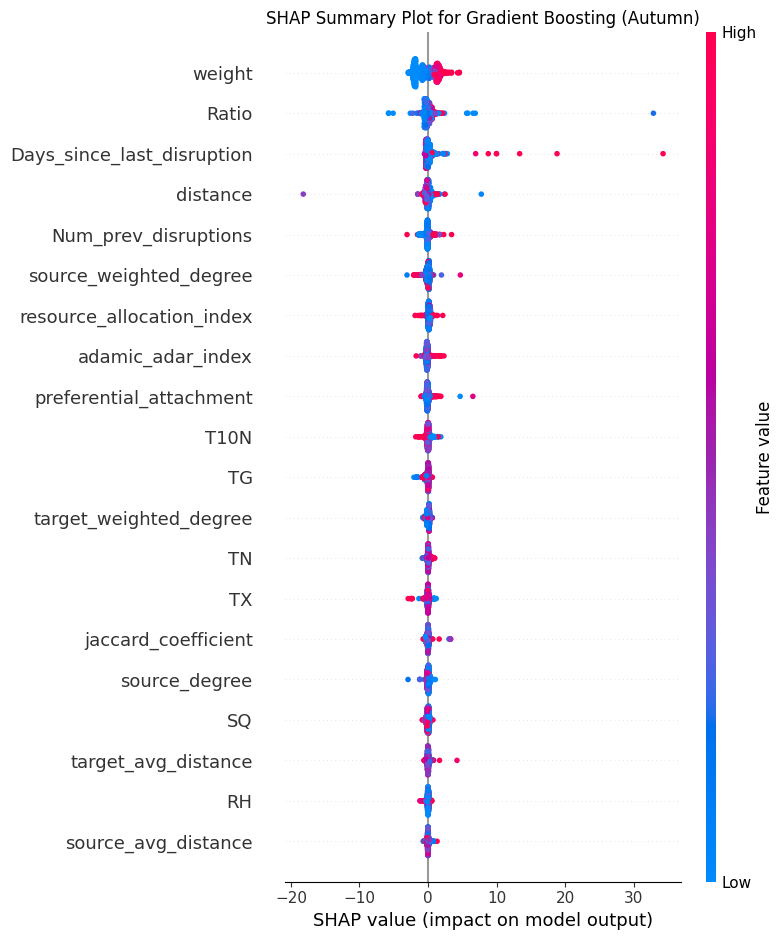

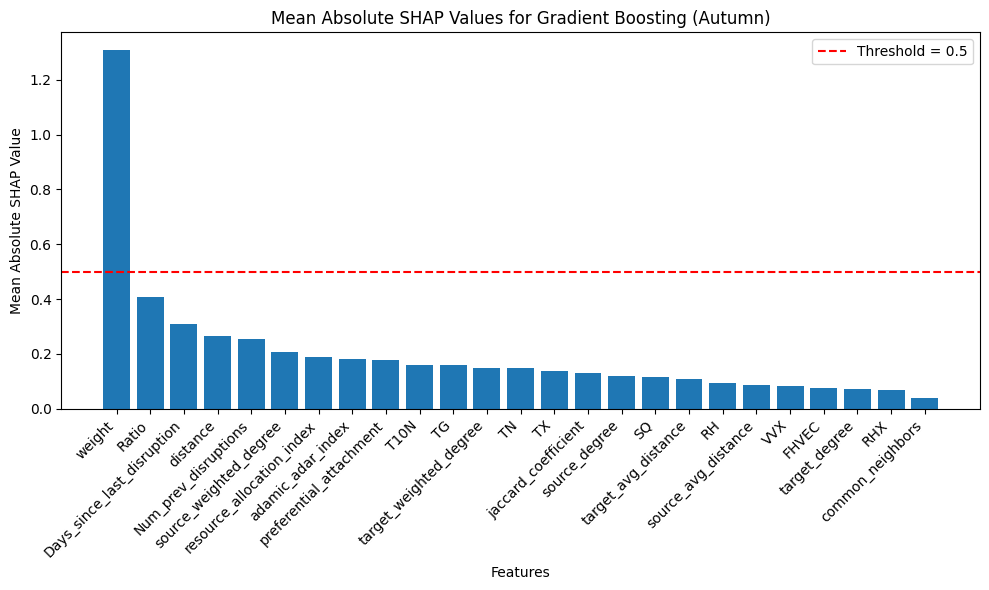

In [56]:
for season in seasons:
    X = seasonal_splits[season]
    val_data = split_season_by_year(X, season)
    val_data[f'{season} 2023']
    feature_cols = topo_features + wthr_features + oper_features
    shap_values = plot_shap_values(gb_models[season], X[feature_cols], feature_cols, model_type='gradient_boosting', season=season)

In [57]:
feature_selection_gb = {}
for season in seasons:
    X = seasonal_splits[season]
    val_data = split_season_by_year(X, season)
    val_data = val_data[f'{season} 2023']
    feature_cols = topo_features + wthr_features + oper_features
    print(gb_models[season].classes_) 
    selected_features_df = shap_select(
        gb_models[season],
        val_data[feature_cols],
        val_data['Disrupted'].astype(int),
        feature_names=feature_cols,
        task="binary",
        threshold=0.05
    )
    print(f"Selected features for {season}:")
    print(selected_features_df)
    selected_features_df = selected_features_df[selected_features_df['selected'] == 1]
    sel_feat_list = selected_features_df['feature name'].tolist()
    feature_selection_gb[season] = sel_feat_list
    print(sel_feat_list)

[0 1]


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-pa

Selected features for Winter:
                  feature name    t-value  stat.significance  coefficient  \
0      preferential_attachment  28.260619      1.053983e-175     0.191881   
1             common_neighbors  15.564025       1.278028e-54     0.403733   
2                       weight   9.813862       9.813872e-23     0.002526   
3                        Ratio   9.711665       2.689074e-22     0.223259   
4                           RH   7.928225       2.222994e-15     0.138079   
5   Days_since_last_disruption   4.924202       8.470529e-07     0.000009   
6                          RHX   4.714463       2.423493e-06     0.000263   
7                source_degree   4.352127       1.348232e-05     0.003851   
8          source_avg_distance   3.848151       1.190128e-04     0.002867   
9                target_degree   3.408076       6.542271e-04     0.253718   
10                          TN   3.168881       1.530270e-03     0.111022   
11        Num_prev_disruptions   3.074658     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Spring:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  42.216237       0.000000e+00     0.865616   
1   Days_since_last_disruption  26.081309      5.941459e-150     0.757769   
2                        Ratio  13.118703       2.572991e-39     0.776133   
3         Num_prev_disruptions   8.259036       1.468537e-16     0.349798   
4                           TX   5.090831       3.564980e-07     0.468197   
5                target_degree   4.551751       5.320139e-06     1.016455   
6       source_weighted_degree   4.142548       3.434688e-05     0.403580   
7            adamic_adar_index   3.003370       2.670076e-03     0.030515   
8                     distance   2.706801       6.793497e-03     0.311971   
9                           TG   2.331636       1.971982e-02     0.241476   
10            common_neighbors   0.925459       3.547272e-01     0.751792   
11                       FHVEC   0.224075     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-pa

Selected features for Summer:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  41.500024       0.000000e+00     0.868334   
1         Num_prev_disruptions  12.446680       1.457836e-35     0.304128   
2            adamic_adar_index   8.926659       4.390694e-19     0.381650   
3                        Ratio   8.845957       9.074686e-19     0.270941   
4                target_degree   5.388420       7.107964e-08     0.800353   
5                           RH   2.972660       2.952317e-03     0.026521   
6   Days_since_last_disruption   2.604292       9.206425e-03     0.090477   
7                           TX   2.450142       1.427999e-02     0.250759   
8      preferential_attachment   2.110023       3.485641e-02     0.104741   
9          source_avg_distance   1.755335       7.920207e-02     0.166742   
10                         RHX   1.408357       1.590254e-01     0.164869   
11                        T10N   1.396018     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Autumn:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  40.582060       0.000000e+00     0.750335   
1                     distance  11.014729       3.245118e-28     0.713554   
2                        Ratio  10.688015       1.158232e-26     0.152036   
3             common_neighbors   7.754684       8.856386e-15     1.466295   
4       target_weighted_degree   4.817123       1.456428e-06     0.501409   
5      preferential_attachment   4.713724       2.432301e-06     0.307912   
6            adamic_adar_index   2.912221       3.588691e-03     0.232418   
7                          VVX   2.827954       4.684656e-03     0.434787   
8          source_avg_distance   2.620660       8.775981e-03     0.207191   
9                source_degree   1.984689       4.717914e-02     0.267199   
10               target_degree   1.303938       1.922549e-01     0.255632   
11      source_weighted_degree   1.283207     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 4 out of 4 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 3 out of 3 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning:

In [58]:
gb_models_selected = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    train_data = pd.concat([test_data[year] for year in test_data if year != f'{season} 2024'])
    test_data = test_data[f'{season} 2024']
    
    # Extract selected features
    selected_features = feature_selection_gb[season]
    
    # Prepare training and testing data
    X_train = train_data[selected_features]
    y_train = train_data['Disrupted'].astype(int)
    X_test = test_data[selected_features]
    y_test = test_data['Disrupted'].astype(int)
    
    # Train the XGBoost model
    model = GradientBoostingClassifier(random_state=42, **gb_params[season])
    model.fit(X_train, y_train)
    
    # Store the trained model
    gb_models_selected[season] = model
    
    # Evaluate the model
    y_pred = model.predict(X_test)
    print(f"Season: {season}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

Season: Winter
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2651
           1       0.20      0.32      0.25       210

    accuracy                           0.86      2861
   macro avg       0.57      0.61      0.58      2861
weighted avg       0.89      0.86      0.87      2861

Accuracy: 0.8570
F1 Score: 0.2468
Precision: 0.2012
Recall: 0.3190
Balanced Accuracy: 0.6094
AUC: 0.7460
Season: Spring
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92     17463
           1       0.31      0.38      0.34      1984

    accuracy                           0.85     19447
   macro avg       0.62      0.64      0.63     19447
weighted avg       0.86      0.85      0.86     19447

Accuracy: 0.8501
F1 Score: 0.3380
Precision: 0.3076
Recall: 0.3750
Balanced Accuracy: 0.6395
AUC: 0.7900
Season: Summer
Classification Report:
              precisio

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 0.001}
Best F1 Score: 0.36521709814911263
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     16755
           1       0.26      0.71      0.38      2335

    accuracy                           0.71     19090
   macro avg       0.60      0.71      0.60     19090
weighted avg       0.86      0.71      0.76     19090

Accuracy: 0.7133
F1 Score: 0.3763
Precision: 0.2563
Recall: 0.7071
Balanced Accuracy: 0.7106
AUC: 0.7857


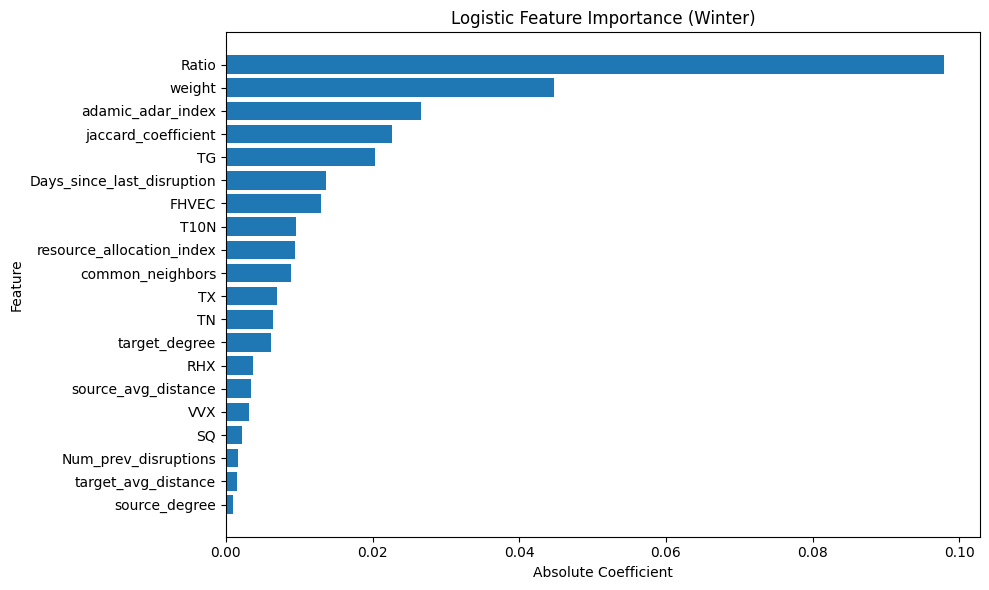

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'saga', 'penalty': 'l1', 'C': 0.1}
Best F1 Score: 0.42991296147754293
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     16987
           1       0.27      0.71      0.39      2604

    accuracy                           0.71     19591
   macro avg       0.61      0.71      0.60     19591
weighted avg       0.85      0.71      0.75     19591

Accuracy: 0.7063
F1 Score: 0.3915
Precision: 0.2701
Recall: 0.7108
Balanced Accuracy: 0.7082
AUC: 0.7847


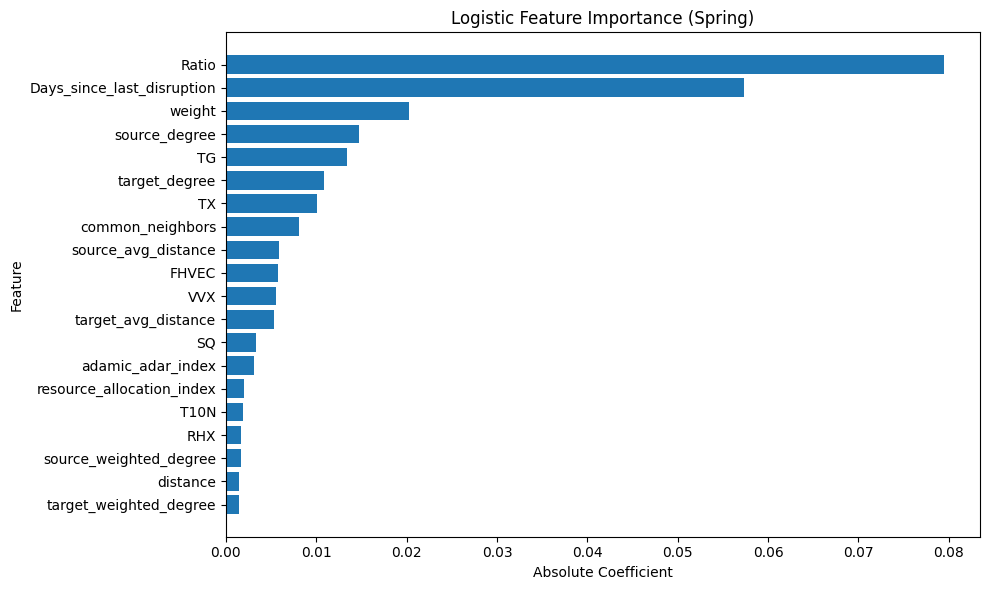

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
Best F1 Score: 0.3901826201327974
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.67      0.79     16774
           1       0.26      0.76      0.38      2483

    accuracy                           0.68     19257
   macro avg       0.60      0.72      0.59     19257
weighted avg       0.86      0.68      0.74     19257

Accuracy: 0.6848
F1 Score: 0.3824
Precision: 0.2559
Recall: 0.7567
Balanced Accuracy: 0.7155
AUC: 0.7905


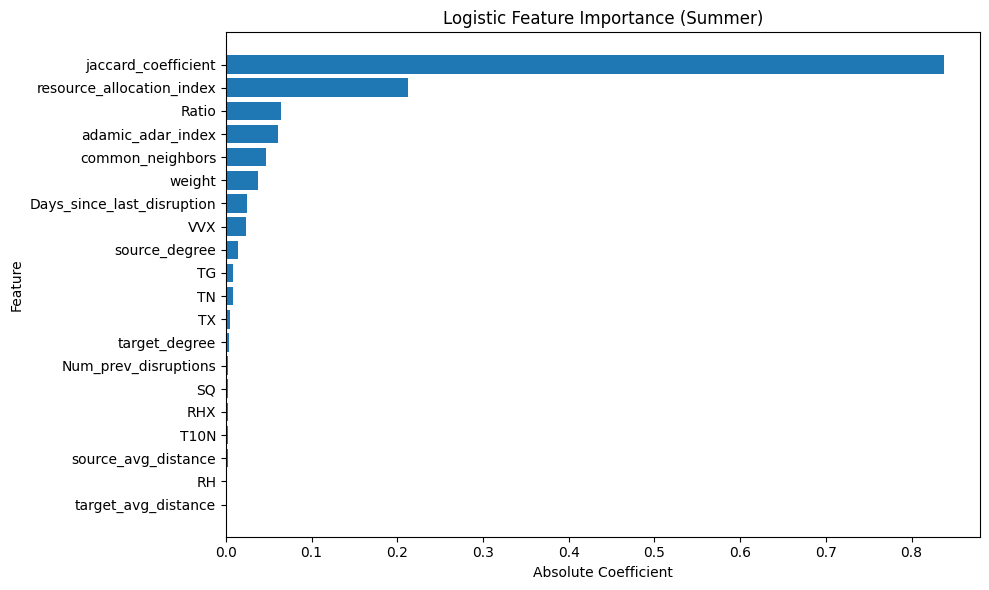

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
Best F1 Score: 0.4072318061084788
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     16645
           1       0.28      0.72      0.40      2592

    accuracy                           0.71     19237
   macro avg       0.61      0.72      0.61     19237
weighted avg       0.85      0.71      0.76     19237

Accuracy: 0.7125
F1 Score: 0.4026
Precision: 0.2796
Recall: 0.7191
Balanced Accuracy: 0.7153
AUC: 0.7861


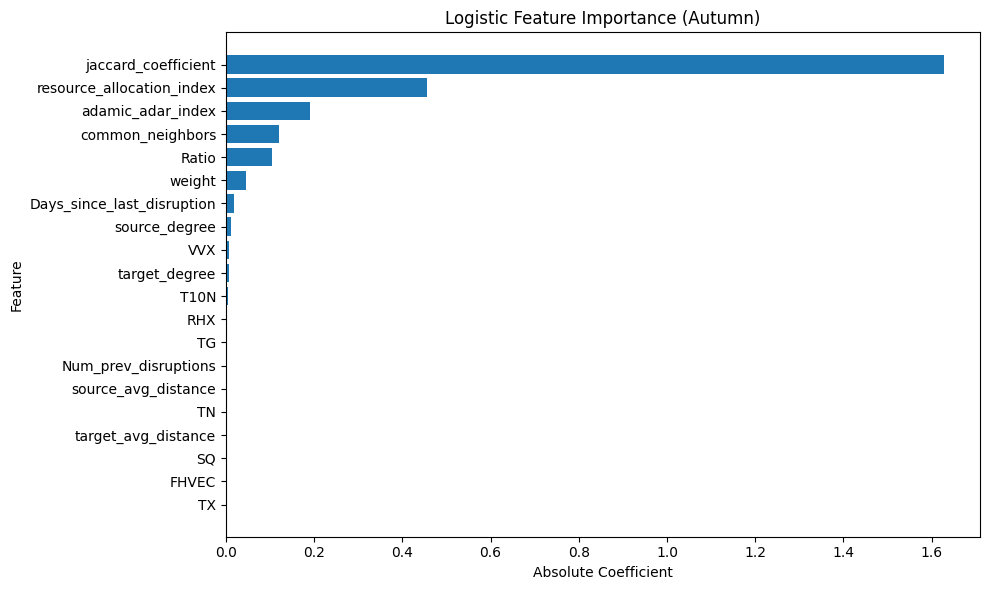

In [59]:
lr_models = {}
lr_params = {}
lr_features = {}

for season in seasons:
    X = seasonal_splits[season]
    lr_models[season], lr_params[season] = optimise(logres, scoring, param_grid_lr, X, season)

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [06:50<00:00,  2.44it/s]


[6.58401298e-06 2.01471486e-03 6.03650485e-03 9.07229754e-03
 6.76963228e-04 1.30819260e-03 1.29214753e-04 0.00000000e+00
 2.65571220e-03 5.63360629e-04 0.00000000e+00 1.20990979e-01
 2.82980874e-04 4.91541761e-02 1.01074548e-01 3.62549811e-02
 3.28193022e-02 6.24832721e-02 6.18295275e-03 1.40950172e-03
 2.18145968e-03 4.59311837e-04 5.56521215e-02 2.95604967e-02
 2.36662347e-02]


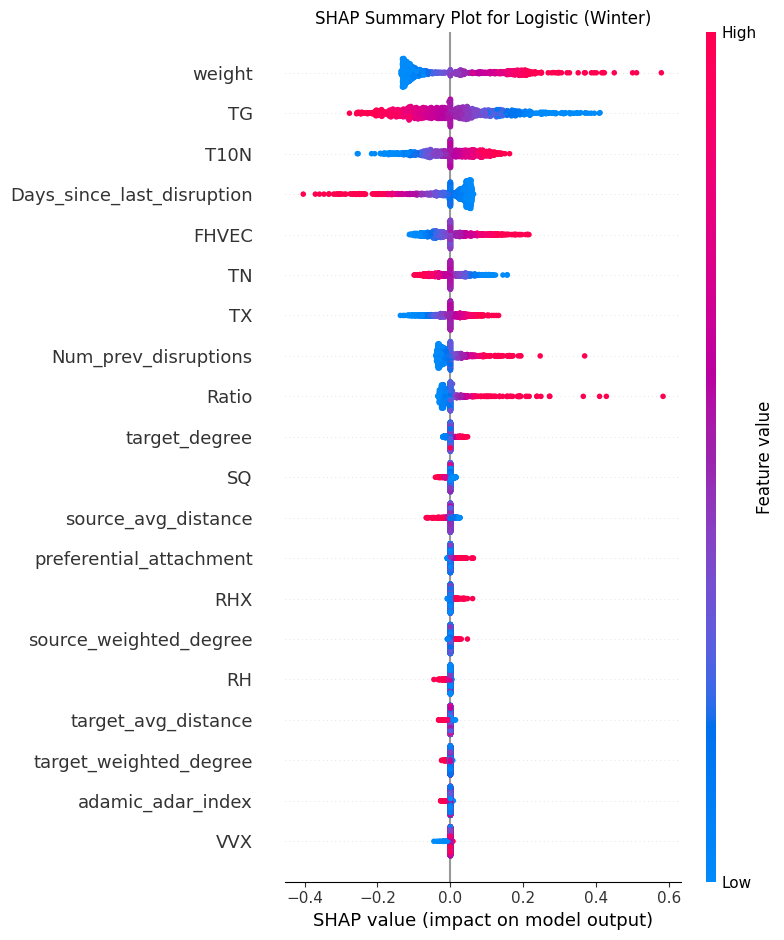

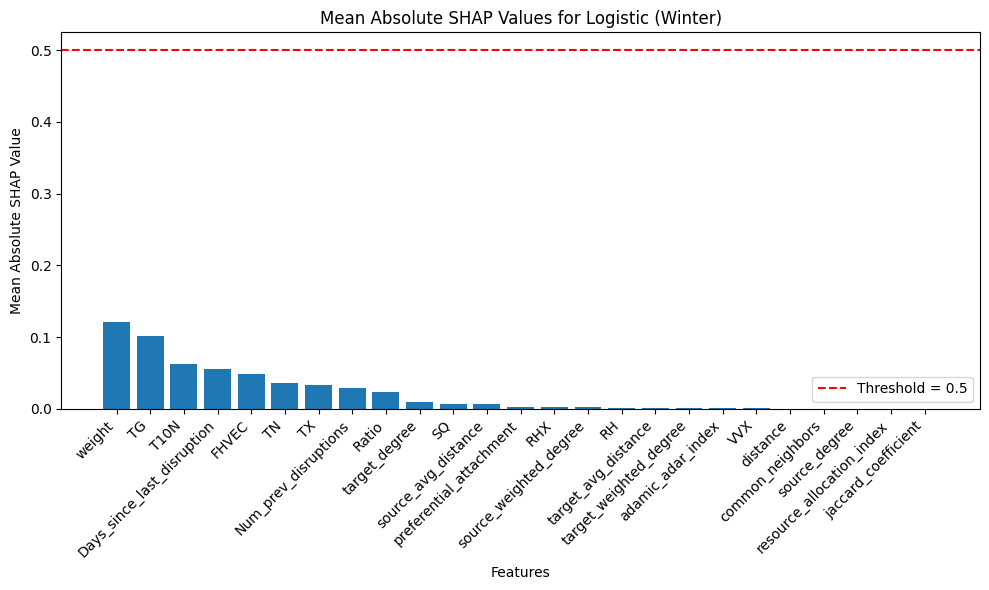

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [06:47<00:00,  2.45it/s]


[2.44264463e-02 2.96053787e-02 1.00087596e-02 1.54096160e-02
 2.34914120e-02 9.26343395e-03 8.43815217e-06 0.00000000e+00
 6.31400072e-03 0.00000000e+00 0.00000000e+00 5.05662266e-02
 6.10178336e-03 8.27629907e-03 8.55226042e-02 3.13614978e-04
 7.37488189e-02 6.92394145e-03 1.68148723e-02 1.50134659e-03
 6.77034257e-04 2.72573014e-04 1.46583161e-01 1.41368963e-02
 1.52711671e-02]


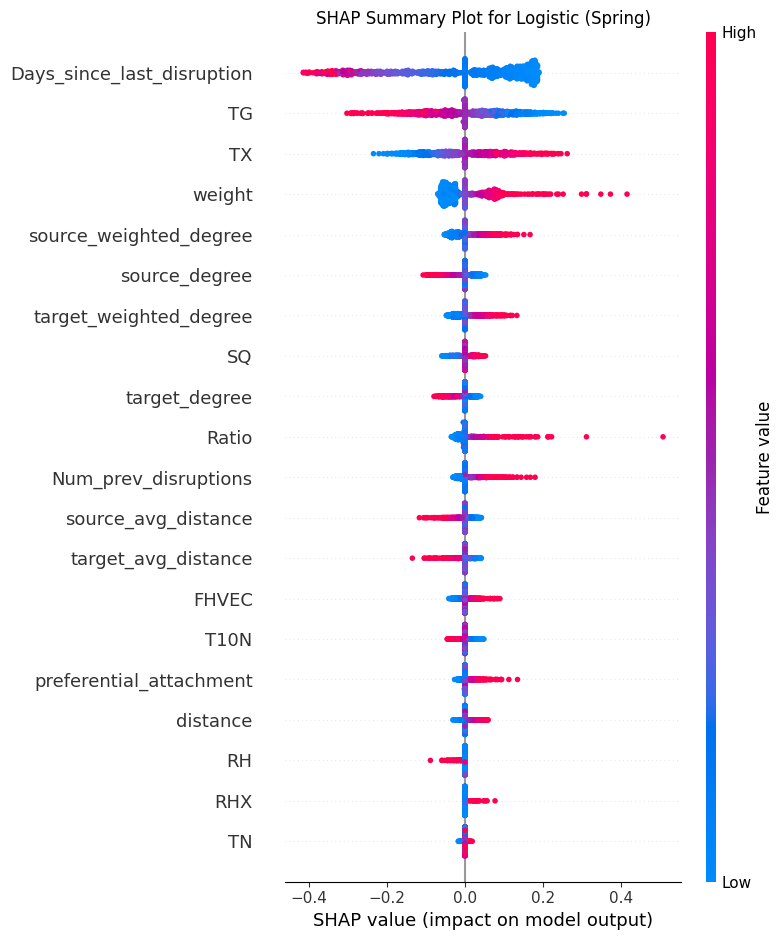

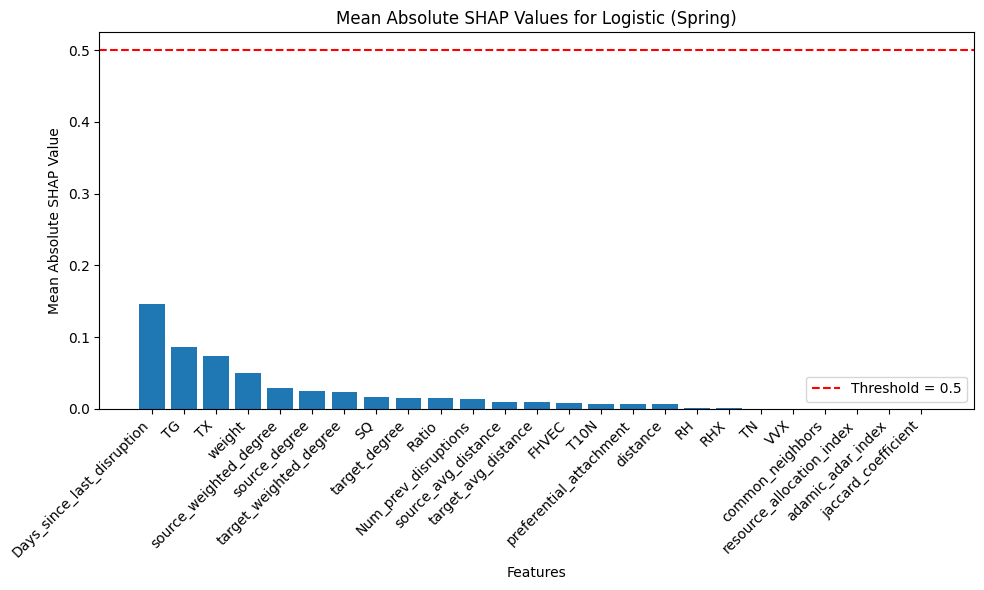

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [06:46<00:00,  2.46it/s]


[0.02406472 0.01373103 0.00113413 0.00291846 0.00156584 0.00085655
 0.00943471 0.00653939 0.         0.00303364 0.00309947 0.10598453
 0.0044571  0.00013884 0.03335711 0.0299496  0.02597837 0.00478002
 0.01223493 0.00459708 0.00213301 0.00579174 0.08704274 0.06029578
 0.01146771]


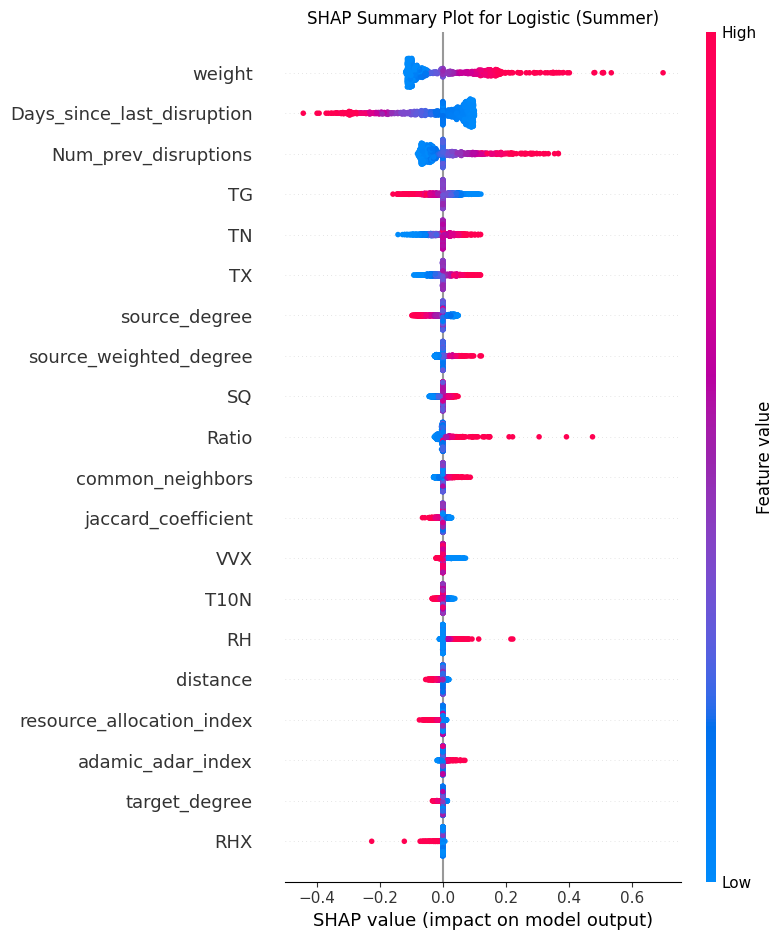

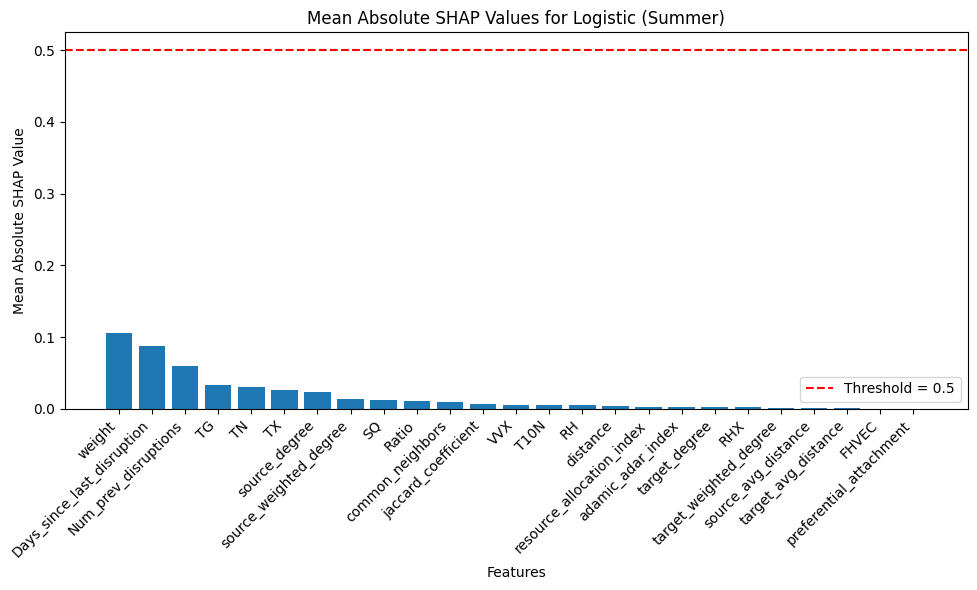

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [06:46<00:00,  2.46it/s]


[0.02221607 0.00722095 0.00098355 0.00671532 0.00018164 0.00074086
 0.03313364 0.01978854 0.         0.02634117 0.01542084 0.12354869
 0.00250572 0.00013335 0.01153283 0.00447198 0.00134593 0.02748891
 0.00061989 0.         0.00125894 0.00287968 0.07639415 0.04350306
 0.01675364]


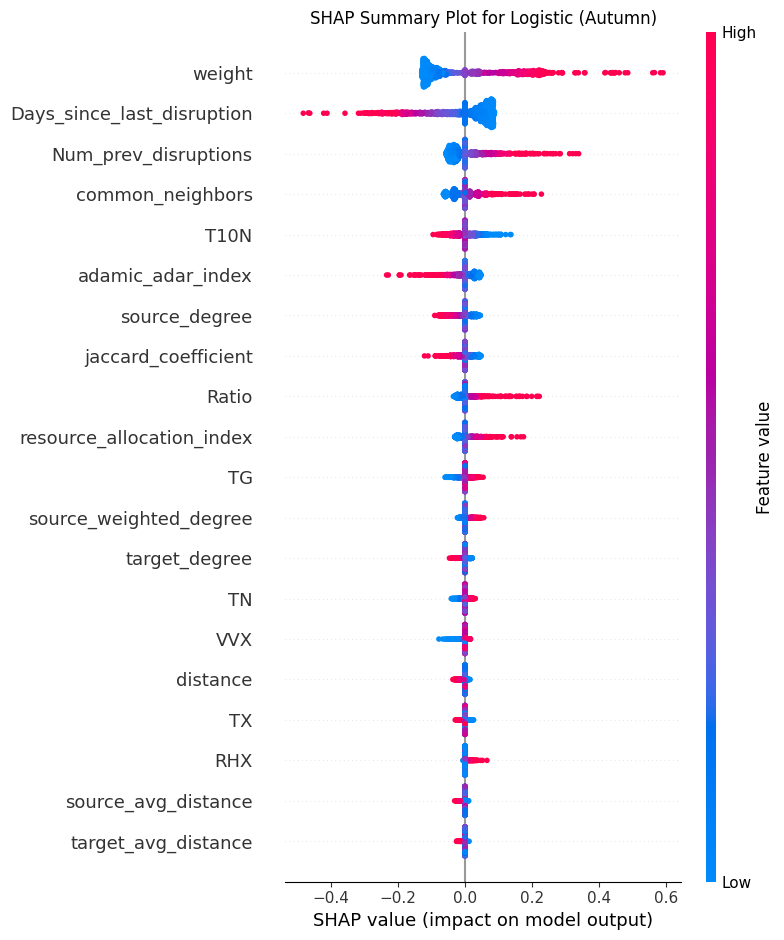

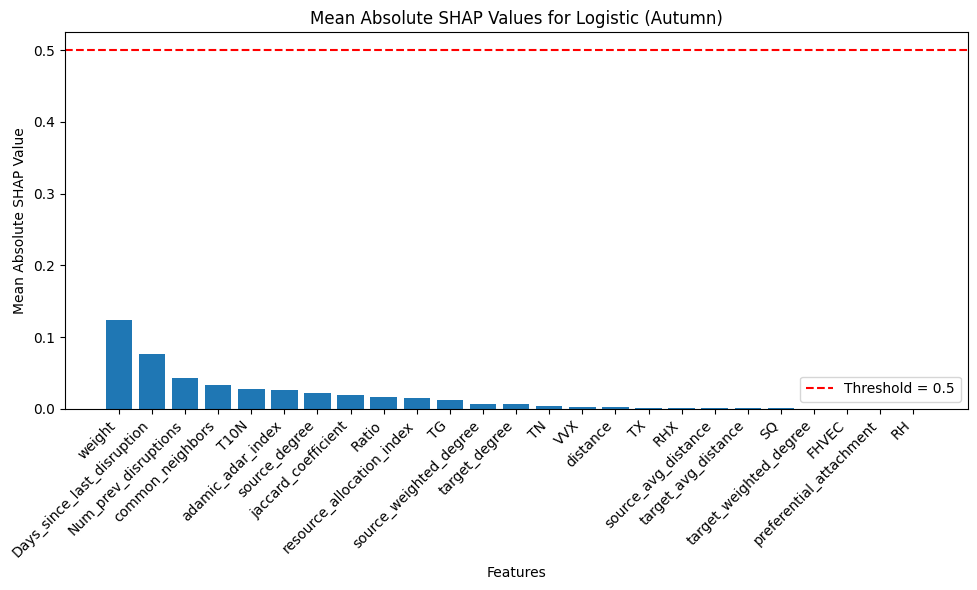

In [60]:
lr_shap_values = {}
for season in seasons:
    X = seasonal_splits[season]
    val_data = split_season_by_year(X, season)
    val_data[f'{season} 2023']
    feature_cols = topo_features + wthr_features + oper_features
    shap_values = plot_shap_values(lr_models[season], X[feature_cols], feature_cols, model_type='logistic', season=season)
    lr_shap_values[season] = shap_values

In [61]:
lr_top_features = {}

for season in seasons:
    shap_values = lr_shap_values[season]
    mean_shap_values = np.abs(shap_values).mean(axis=0)
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': mean_shap_values
    }).sort_values(by='Importance', ascending=False)
    
    lr_top_features[season] = feature_importance['Feature'].head(10).tolist()

print(lr_top_features)

{'Winter': ['weight', 'TG', 'T10N', 'Days_since_last_disruption', 'FHVEC', 'TN', 'TX', 'Num_prev_disruptions', 'Ratio', 'target_degree'], 'Spring': ['Days_since_last_disruption', 'TG', 'TX', 'weight', 'source_weighted_degree', 'source_degree', 'target_weighted_degree', 'SQ', 'target_degree', 'Ratio'], 'Summer': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'TG', 'TN', 'TX', 'source_degree', 'source_weighted_degree', 'SQ', 'Ratio'], 'Autumn': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'common_neighbors', 'T10N', 'adamic_adar_index', 'source_degree', 'jaccard_coefficient', 'Ratio', 'resource_allocation_index']}


In [21]:
best_parameters_lr = {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
best_parameters_xgb = {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': 1.0}
best_parameters_rf = {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}
best_parameters_gb = {'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}

In [71]:
from sklearn.utils import resample

def bootstrap_f1_scores(model, X, y, n_iterations=100):
    scores = []
    for _ in range(n_iterations):
        X_resampled, y_resampled = resample(X, y)
        y_pred_proba = model.predict(X_resampled, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        scores.append(f1_score(y_resampled, y_pred, average='weighted'))  # or 'macro'
    return np.array(scores)

In [65]:
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from bayes_opt import BayesianOptimization

def build_lstm_model(input_shape, lstm1, lstm2, dense, learning_rate):
    model = Sequential([
        LSTM(int(lstm1), activation='relu', return_sequences=True, input_shape=input_shape),
        LSTM(int(lstm2), activation='relu'),
        Dropout(0.3),
        Dense(int(dense), activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def optimise_lstm_bayesian(seasonal_data, season, init_points=5, n_iter=10, epochs=50, batch_size=32):
    seasonal_years = split_season_by_year(seasonal_data, season)
    years = sorted(seasonal_years.keys())
    
    # Split train/test
    train_df = pd.concat([seasonal_years[year] for year in years[:-2]])
    val_df = seasonal_years[years[-2]]
    test_df = seasonal_years[years[-1]]
    
    X_train = train_df[feature_cols]
    y_train = train_df["Disrupted"].values
    X_val = val_df[feature_cols]
    y_val = val_df["Disrupted"].values
    X_test = test_df[feature_cols]
    y_test = test_df["Disrupted"].values
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_val_scaled = scaler.transform(X_val).reshape((X_val.shape[0], 1, X_val.shape[1]))
    X_test_scaled = scaler.transform(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)
    
    # Determine input shape
    num_features = X_train.shape[1]
    input_shape = (1, num_features)  # 1 timestep, N features

    # Objective function for Bayesian Optimization
    def train_eval(lstm1, lstm2, dense, learning_rate):
        model = build_lstm_model(input_shape, lstm1, lstm2, dense, learning_rate)
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(X_train_scaled, y_train_cat, epochs=epochs, batch_size=batch_size,
                  validation_split=0.2, callbacks=[es], verbose=0)
        y_pred = model.predict(X_val_scaled)
        return f1_score(y_val, np.argmax(y_pred, axis=1))
    
    pbounds = {
        'lstm1': (32, 256),
        'lstm2': (16, 128),
        'dense': (16, 128),
        'learning_rate': (1e-4, 1e-2)
    }
    
    optimizer = BayesianOptimization(f=train_eval, pbounds=pbounds, random_state=42)
    optimizer.maximize(init_points=init_points, n_iter=n_iter)
    
    # Train best model
    best_params = optimizer.max['params']
    final_model = build_lstm_model(input_shape, **best_params)
    final_model.fit(X_train_scaled, y_train_cat, epochs=epochs, batch_size=batch_size,
                    validation_split=0.2, verbose=0)
    
    y_pred_final = final_model.predict(X_val_scaled)
    y_pred_classes = np.argmax(y_pred_final, axis=1)

    # Report
    print("\nBest Hyperparameters:", best_params)
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred_classes))

    cm = confusion_matrix(y_val, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {season} 2023')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    metrics = {
        'f1': f1_score(y_val, y_pred_classes),
        'balanced_acc': balanced_accuracy_score(y_val, y_pred_classes),
        'auc': roc_auc_score(y_val, y_pred_final[:, 1])
    }
    
    return final_model, best_params, metrics

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 1         | 0.3028    | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
| 2         | 0.2767    | 33.47     | 0.001644  | 45.01     | 113.0     |


...

597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
| 39        | 0.3132    | 96.22     | 0.0006195 | 138.3     | 35.69     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
| 40        | 0.2162    | 116.8     | 0.00218   | 135.3     | 32.1      |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Best Hyperparameters: {'dense': 53.62708566133843, 'learning_rate': 0.0024928488620810743, 'lstm1': 130.54480224984326, 'lstm2': 50.90562476061952}

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.95      0.93     16755
        True       0.42      0.24      0.31      2335

    accuracy                           0.87     19090
   macro avg       0.66      0.60      0.62     19090
weighted avg       0.84      0.87      0.85     19090



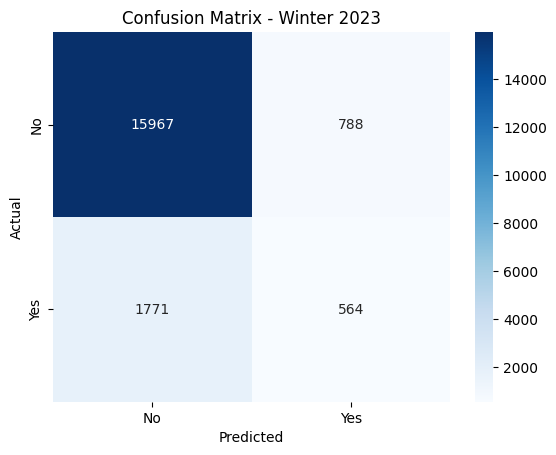

In [66]:
X_winter = seasonal_splits['Winter']
lstm_model_winter, lstm_params_winter, lstm_metrics_winter = optimise_lstm_bayesian(X_winter, 'Winter', init_points=10, n_iter=30, epochs=50, batch_size=32)

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 1         | 0.1562    | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 2         | 0.1556    | 33.47     | 0.001644  | 45.01     | 113.0     |


...

613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
| 39        | 0.2925    | 96.22     | 0.0006195 | 138.3     | 35.69     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
| 40        | 0.298     | 116.8     | 0.00218   | 135.3     | 32.1      |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Best Hyperparameters: {'dense': 50.12174783974884, 'learning_rate': 0.0006977223114061992, 'lstm1': 127.4338232936334, 'lstm2': 49.68054391082301}

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.94      0.92     16987
        True       0.43      0.30      0.35      2604

    accuracy                           0.85     19591
   macro avg       0.66      0.62      0.63     19591
weighted avg       0.83      0.85      0.84     19591



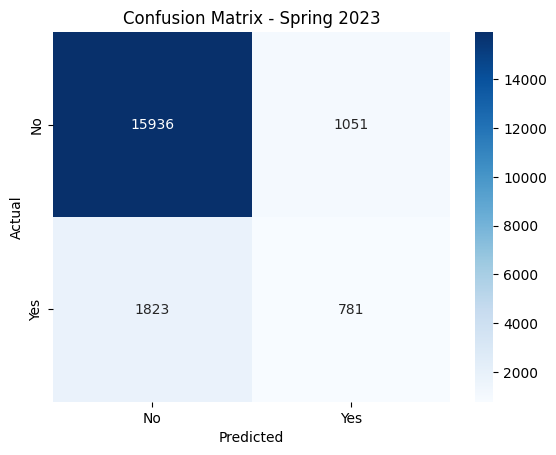

In [67]:
X_spring = seasonal_splits['Spring']
lstm_model_spring, lstm_params_spring, lstm_metrics_spring = optimise_lstm_bayesian(X_spring, 'Spring', init_points=10, n_iter=30, epochs=50, batch_size=32)

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 1         | 0.3176    | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
| 2         | 0.2943    | 33.47     | 0.001644  | 45.01     | 113.0     |


...

602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 39        | 0.2782    | 96.22     | 0.0006195 | 138.3     | 35.69     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 40        | 0.3245    | 116.8     | 0.00218   | 135.3     | 32.1      |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Best Hyperparameters: {'dense': 68.80912732003533, 'learning_rate': 0.0016888516126857746, 'lstm1': 211.63911630290744, 'lstm2': 26.808338331294195}

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.94      0.92     16774
        True       0.39      0.27      0.32      2483

    accuracy                           0.85     19257
   macro avg       0.64      0.60      0.62     19257
weighted avg       0.83      0.85      0.84     19257



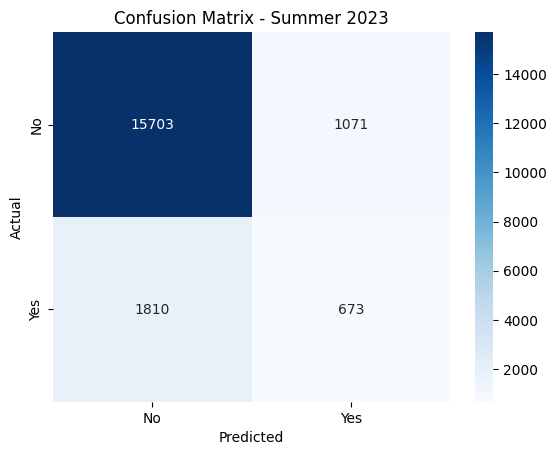

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 1         | 0.2801    | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 2         | 0.2781    | 33.47     | 0.001644  | 45.01     | 113.0     |


...

602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 39        | 0.2539    | 96.22     | 0.0006195 | 138.3     | 35.69     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 40        | 0.2843    | 116.8     | 0.00218   | 135.3     | 32.1      |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Best Hyperparameters: {'dense': 99.17109816554105, 'learning_rate': 0.005298333987055072, 'lstm1': 99.27620366082166, 'lstm2': 18.20377664247697}

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.98      0.93     16645
        True       0.53      0.15      0.24      2592

    accuracy                           0.87     19237
   macro avg       0.71      0.57      0.58     19237
weighted avg       0.83      0.87      0.83     19237



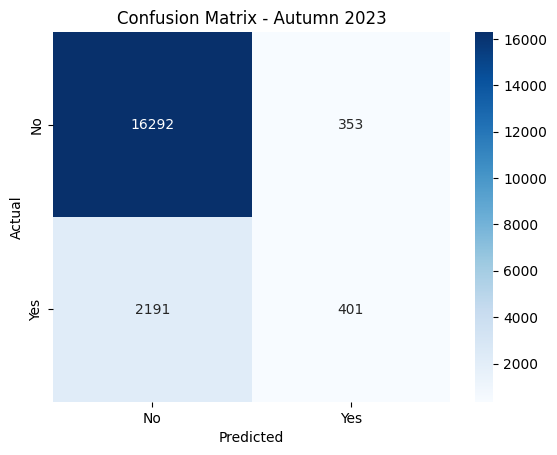

In [68]:
X_summer = seasonal_splits['Summer']
lstm_model_summer, lstm_params_summer, lstm_metrics_summer = optimise_lstm_bayesian(X_summer, 'Summer', init_points=10, n_iter=30, epochs=50, batch_size=32)
X_autumn = seasonal_splits['Autumn']
lstm_model_autumn, lstm_params_autumn, lstm_metrics_autumn = optimise_lstm_bayesian(X_autumn, 'Autumn', init_points=10, n_iter=30, epochs=50, batch_size=32)

Initial 2023 Evaluation
              precision    recall  f1-score   support

       False       0.89      0.97      0.93     16755
        True       0.43      0.18      0.26      2335

    accuracy                           0.87     19090
   macro avg       0.66      0.57      0.59     19090
weighted avg       0.84      0.87      0.85     19090



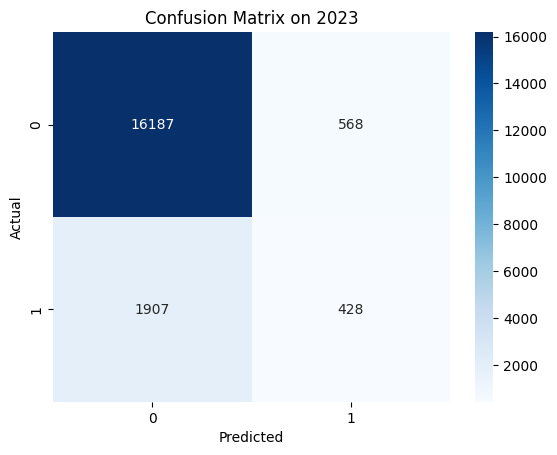

Bootstrapping F1 Scores for 2023 Data (100 iterations)...
Mean F1: 0.8471 ± 0.0030


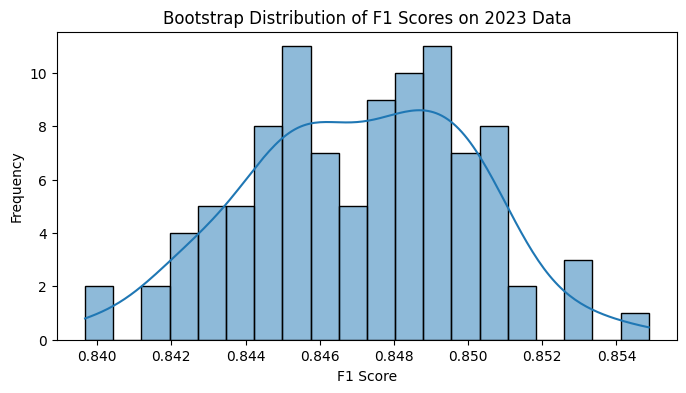

Computing permutation importance on 2023 test set...


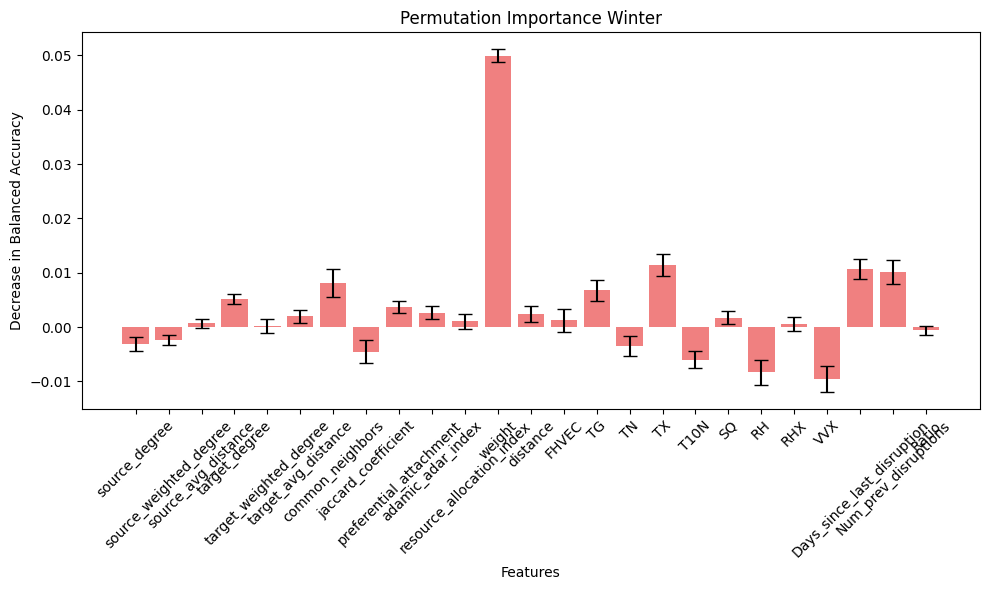

In [75]:
import copy

def permutation_importance(model, X_test, y_test, metric, feature_names, n_repeats=5):
    """
    Compute permutation importance for an LSTM model.
    
    Parameters:
    - model: Trained Keras LSTM model
    - X_test: Test data, shape [samples, timesteps, n_features]
    - y_test: Test labels (categorical, shape [samples, n_classes])
    - metric: Metric function (e.g., balanced_accuracy_score)
    - feature_names: List of feature names
    - n_repeats: Number of times to shuffle each feature
    
    Returns:
    - mean_importance: Mean importance scores for each feature
    - std_importance: Standard deviation of importance scores
    """
    # Baseline performance
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = y_test
    baseline_score = metric(y_true, y_pred)
    
    # Initialize importance scores
    n_features = X_test.shape[-1]
    importances = np.zeros((n_features, n_repeats))
    
    # Permute each feature
    for feature_idx in range(n_features):
        for repeat in range(n_repeats):
            X_permuted = copy.deepcopy(X_test)
            # Shuffle the feature across samples
            permuted_indices = np.random.permutation(X_test.shape[0])
            X_permuted[:, :, feature_idx] = X_permuted[permuted_indices, :, feature_idx]
            # Evaluate model
            y_pred_proba_permuted = model.predict(X_permuted, verbose=0)
            y_pred_permuted = np.argmax(y_pred_proba_permuted, axis=1)
            permuted_score = metric(y_true, y_pred_permuted)
            # Importance = decrease in metric (since higher is better)
            importances[feature_idx, repeat] = baseline_score - permuted_score
    
    # Average importance and standard deviation
    mean_importance = np.mean(importances, axis=1)
    std_importance = np.std(importances, axis=1)
    return mean_importance, std_importance

def lstm_bootstrap_predict(X_test, y_test, model, feature_names=None, n_iterations=100, season='Winter'):
    # Standardize
    scaler = StandardScaler()
    X_test_scaled = scaler.fit_transform(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))

    # y_test should already be integer labels like 0 or 1
    y_true = y_test

    # Evaluate once on actual 2024 data
    y_pred_proba = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)  # Convert probabilities to categorical labels

    print("Initial 2023 Evaluation")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix on 2023")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Bootstrapping
    print(f"Bootstrapping F1 Scores for 2023 Data ({n_iterations} iterations)...")
    scores = bootstrap_f1_scores(model, X_test_scaled, y_true, n_iterations=n_iterations)

    print(f"Mean F1: {scores.mean():.4f} ± {scores.std():.4f}")

    # Plot distribution
    plt.figure(figsize=(8, 4))
    sns.histplot(scores, bins=20, kde=True)
    plt.title("Bootstrap Distribution of F1 Scores on 2023 Data")
    plt.xlabel("F1 Score")
    plt.ylabel("Frequency")
    plt.show()

    # Permutation importance
    print("Computing permutation importance on 2023 test set...")
    mean_importance, std_importance = permutation_importance(
        model, X_test_scaled, y_true, balanced_accuracy_score, feature_names
    )

    # Plot importance
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(feature_names)), mean_importance, yerr=std_importance, capsize=5, color='lightcoral')
    plt.xticks(range(len(feature_names)), feature_names, rotation=45)
    plt.title(f'Permutation Importance {season}')
    plt.xlabel('Features')
    plt.ylabel('Decrease in Balanced Accuracy')
    plt.tight_layout()
    plt.show()
    n_features = len(feature_names)
    mean_importance = {feature_names[i]: mean_importance[i] for i in range(n_features)}
    std_importance = {feature_names[i]: mean_importance for i in range(n_features)}
    return {
        'f1_scores': scores,
        'mean_importance': mean_importance,
        'std_importance': std_importance
    }

X = seasonal_splits['Winter']
X_test_winter = split_season_by_year(X, 'Winter')['Winter 2023']
y_test_winter = X_test_winter['Disrupted']

lstm_winter_scores = lstm_bootstrap_predict(X_test_winter[feature_cols], y_test_winter, lstm_model_winter, feature_names=feature_cols, n_iterations=100, season='Winter')

Initial 2023 Evaluation
              precision    recall  f1-score   support

       False       0.89      0.91      0.90     16987
        True       0.30      0.26      0.28      2604

    accuracy                           0.82     19591
   macro avg       0.60      0.58      0.59     19591
weighted avg       0.81      0.82      0.82     19591



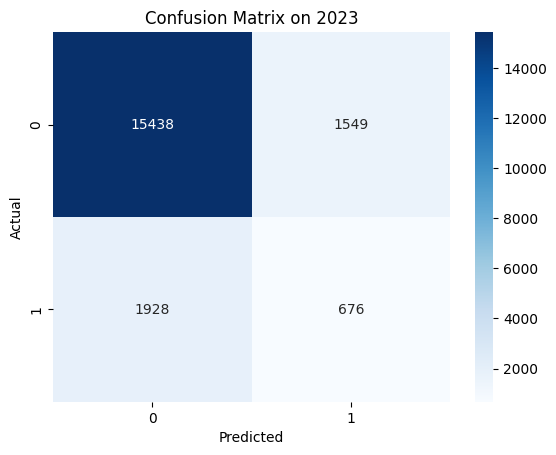

Bootstrapping F1 Scores for 2023 Data (100 iterations)...
Mean F1: 0.8165 ± 0.0031


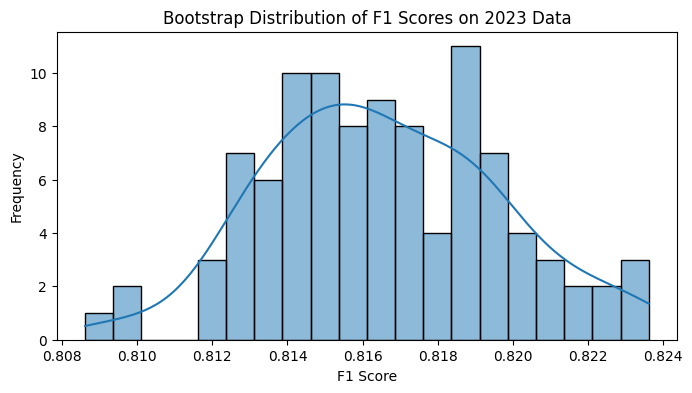

Computing permutation importance on 2023 test set...


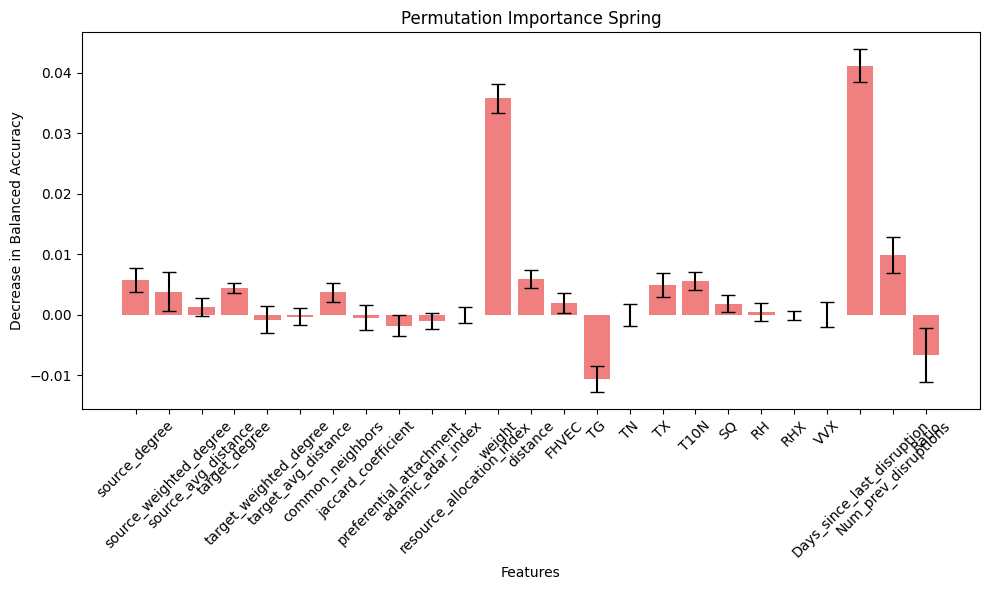

In [76]:
X_spring = seasonal_splits['Spring']
X_test_spring = split_season_by_year(X_spring, 'Spring')['Spring 2023']
y_test_spring = X_test_spring['Disrupted']
lstm_spring_scores = lstm_bootstrap_predict(X_test_spring[feature_cols], y_test_spring, lstm_model_spring, feature_names=feature_cols, n_iterations=100, season='Spring')

Initial 2023 Evaluation
              precision    recall  f1-score   support

       False       0.89      0.95      0.92     16774
        True       0.41      0.22      0.29      2483

    accuracy                           0.86     19257
   macro avg       0.65      0.59      0.60     19257
weighted avg       0.83      0.86      0.84     19257



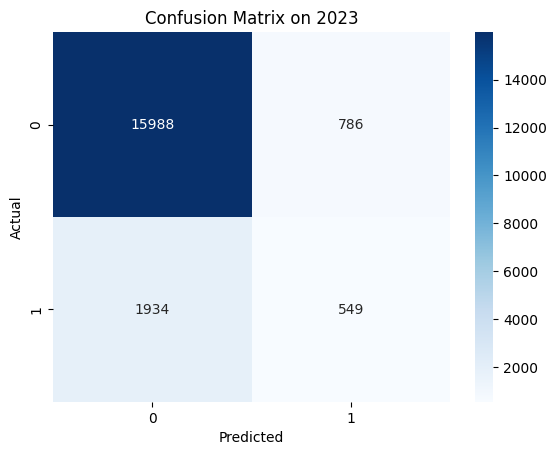

Bootstrapping F1 Scores for 2023 Data (100 iterations)...
Mean F1: 0.8400 ± 0.0031


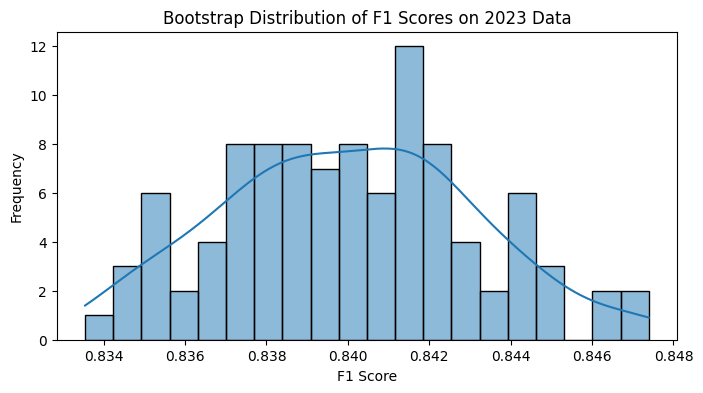

Computing permutation importance on 2023 test set...


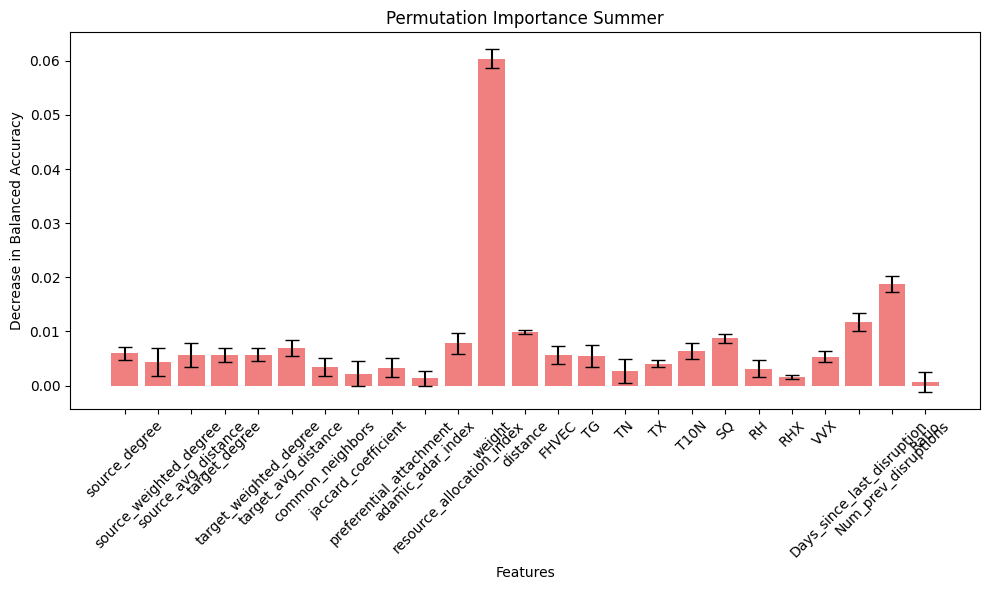

In [77]:
X_summer = seasonal_splits['Summer']
X_test_summer = split_season_by_year(X_summer, 'Summer')['Summer 2023'] 
y_test_summer = X_test_summer['Disrupted']
lstm_summer_scores = lstm_bootstrap_predict(X_test_summer[feature_cols], y_test_summer, lstm_model_summer, feature_names=feature_cols, n_iterations=100, season='Summer')

Initial 2023 Evaluation
              precision    recall  f1-score   support

       False       0.88      0.98      0.93     16645
        True       0.50      0.15      0.23      2592

    accuracy                           0.87     19237
   macro avg       0.69      0.56      0.58     19237
weighted avg       0.83      0.87      0.83     19237



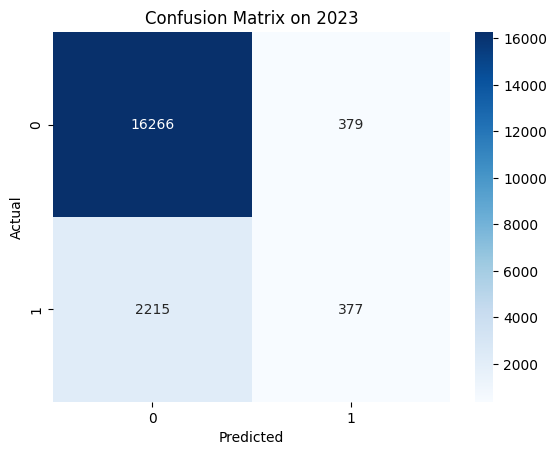

Bootstrapping F1 Scores for 2023 Data (100 iterations)...
Mean F1: 0.8312 ± 0.0034


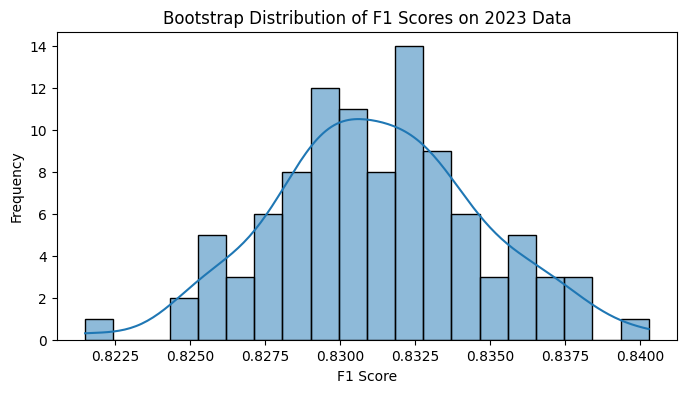

Computing permutation importance on 2023 test set...


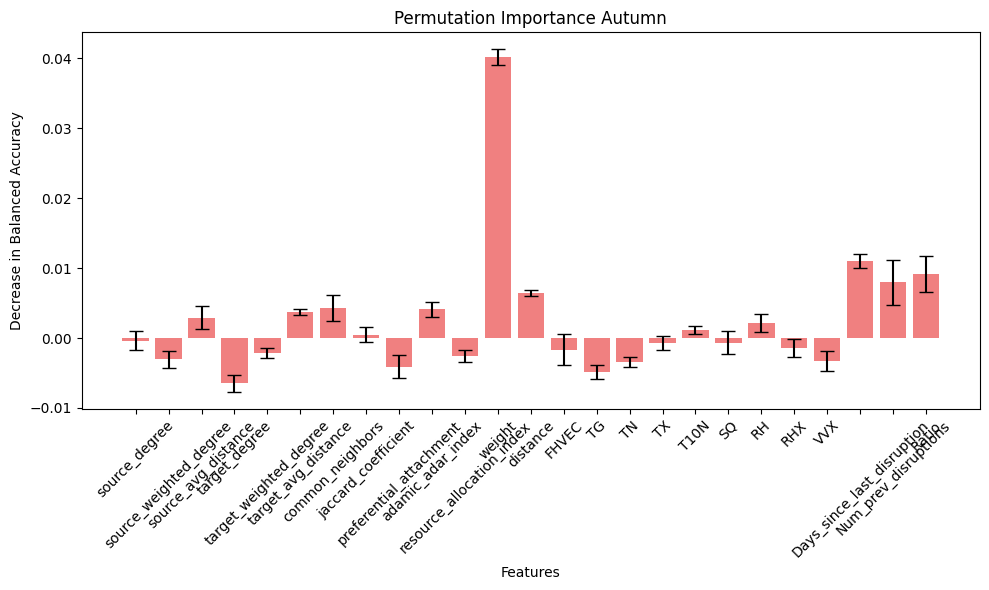

In [78]:
X_autumn = seasonal_splits['Autumn']
X_test_autumn = split_season_by_year(X_autumn, 'Autumn')['Autumn 2023']
y_test_autumn = X_test_autumn['Disrupted']
lstm_autumn_scores = lstm_bootstrap_predict(X_test_autumn[feature_cols], y_test_autumn, lstm_model_autumn, feature_names=feature_cols, n_iterations=100, season='Autumn')
# Combine all LSTM scores into a single DataFrame
lstm_scores = {
    'Winter': lstm_winter_scores,
    'Spring': lstm_spring_scores,
    'Summer': lstm_summer_scores,
    'Autumn': lstm_autumn_scores
}

In [118]:
lstm_features = {}
for season in seasons:
    lstm_scores[season]['mean_importance'] = pd.Series(lstm_scores[season]['mean_importance']).sort_values(ascending=False)
    top_features = lstm_scores[season]['mean_importance'][lstm_scores[season]['mean_importance'] > 0].index.tolist()
    lstm_features[season] = top_features[:10]
    print(f"Top features for {season}: {top_features[:10]}")

Top features for Winter: ['weight', 'TX', 'Days_since_last_disruption', 'Num_prev_disruptions', 'common_neighbors', 'TG', 'target_degree', 'preferential_attachment', 'adamic_adar_index', 'distance']
Top features for Spring: ['Days_since_last_disruption', 'weight', 'Num_prev_disruptions', 'distance', 'source_degree', 'T10N', 'TX', 'target_degree', 'source_weighted_degree', 'common_neighbors']
Top features for Summer: ['weight', 'Num_prev_disruptions', 'Days_since_last_disruption', 'distance', 'SQ', 'resource_allocation_index', 'target_avg_distance', 'T10N', 'source_degree', 'target_degree']
Top features for Autumn: ['weight', 'Days_since_last_disruption', 'Ratio', 'Num_prev_disruptions', 'distance', 'common_neighbors', 'adamic_adar_index', 'target_avg_distance', 'source_avg_distance', 'RH']


In [ ]:
lstm_parameters = {
    'Winter': lstm_params_winter,
    'Spring': lstm_params_spring,
    'Summer': lstm_params_summer,
    'Autumn': lstm_params_autumn
}
print(lstm_parameters)

{'Winter': {'dense': 53.62708566133843, 'learning_rate': 0.0024928488620810743, 'lstm1': 130.54480224984326, 'lstm2': 50.90562476061952}, 'Spring': {'dense': 50.12174783974884, 'learning_rate': 0.0006977223114061992, 'lstm1': 127.4338232936334, 'lstm2': 49.68054391082301}, 'Summer': {'dense': 68.80912732003533, 'learning_rate': 0.0016888516126857746, 'lstm1': 211.63911630290744, 'lstm2': 26.808338331294195}, 'Autumn': {'dense': 99.17109816554105, 'learning_rate': 0.005298333987055072, 'lstm1': 99.27620366082166, 'lstm2': 18.20377664247697}}


In [116]:
print("Logistic Regression Parameters:")
print(lr_params)
print("XGBoost Parameters:")
print(xgb_params)  
print("Random Forest Parameters:")
print(rf_params)
print("Gradient Boosting Parameters:")
print(gb_params) 
print("LSTM Parameters:")
print(lstm_parameters)

Logistic Regression Parameters:
{'Winter': {'solver': 'newton-cg', 'penalty': 'l2', 'C': 0.001}, 'Spring': {'solver': 'saga', 'penalty': 'l1', 'C': 0.1}, 'Summer': {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}, 'Autumn': {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}}
XGBoost Parameters:
{'Winter': {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}, 'Spring': {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}, 'Summer': {'subsample': 0.8, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}, 'Autumn': {'subsample': 0.8, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}}
Random Forest Parameters:
{'Winter': {'n_estimators': 200, 'min_samples_split': 5, 

In [119]:
lstm_models_trained = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    train_data = pd.concat([test_data[year] for year in test_data if year != f'{season} 2024'])
    test_data = test_data[f'{season} 2024']
    
    # Extract selected features
    selected_features = lstm_features[season]
    
    # Prepare training and testing data
    X_train = train_data[selected_features]
    y_train = train_data['Disrupted']
    X_test = test_data[selected_features]
    y_test = test_data['Disrupted']
    
    # One-hot encode the target variable
    y_train_encoded = to_categorical(y_train.astype(int))
    y_test_encoded = to_categorical(y_test.astype(int))
    
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_scaled = scaler.transform(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    # Build and train the LSTM model
    lstm_params_season = lstm_parameters[season]
    model = build_lstm_model(
        input_shape=(1, len(selected_features)),
        lstm1=lstm_params_season['lstm1'],
        lstm2=lstm_params_season['lstm2'],
        dense=lstm_params_season['dense'],
        learning_rate=lstm_params_season['learning_rate']
    )
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    model.fit(
        X_train_scaled, y_train_encoded,
        epochs=50, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Store the trained model
    lstm_models_trained[season] = model
    
    # Evaluate the model
    y_pred = model.predict(X_test_scaled)
    y_pred_classes = np.argmax(y_pred, axis=1)
    print(f"Season: {season}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_classes))
    print(f"Accuracy: {accuracy_score(y_test, y_pred_classes):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred_classes):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_classes):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_classes):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_classes):.4f}")
    print(f"AUC: {roc_auc_score(y_test, y_pred[:, 1]):.4f}")

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Season: Winter
Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.98      0.96      2651
        True       0.50      0.20      0.29       210

    accuracy                           0.93      2861
   macro avg       0.72      0.59      0.63      2861
weighted avg       0.91      0.93      0.91      2861

Accuracy: 0.9266
F1 Score: 0.2905
Precision: 0.5000
Recall: 0.2048
Balanced Accuracy: 0.5943
AUC: 0.7903


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Season: Spring
Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.96      0.94     17463
        True       0.40      0.26      0.32      1984

    accuracy                           0.88     19447
   macro avg       0.66      0.61      0.63     19447
weighted avg       0.87      0.88      0.87     19447

Accuracy: 0.8848
F1 Score: 0.3166
Precision: 0.4008
Recall: 0.2616
Balanced Accuracy: 0.6086
AUC: 0.7994


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Season: Summer
Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.96      0.93     16903
        True       0.44      0.23      0.30      2188

    accuracy                           0.88     19091
   macro avg       0.67      0.60      0.62     19091
weighted avg       0.85      0.88      0.86     19091

Accuracy: 0.8778
F1 Score: 0.3026
Precision: 0.4377
Recall: 0.2313
Balanced Accuracy: 0.5964
AUC: 0.7861


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Season: Autumn
Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.97      0.94     16959
        True       0.50      0.21      0.29      2165

    accuracy                           0.89     19124
   macro avg       0.70      0.59      0.61     19124
weighted avg       0.86      0.89      0.87     19124

Accuracy: 0.8867
F1 Score: 0.2912
Precision: 0.4994
Recall: 0.2055
Balanced Accuracy: 0.5896
AUC: 0.8091


In [125]:
def plot_scores(scores_by_model, season='Winter', scores='F1'):
    df = pd.DataFrame([
        {'Model': model, 'Score': score}
        for model, scores in scores_by_model.items()
        for score in scores
    ])
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')
    plt.title(f"{scores} Score Distribution by Model ({season})")
    plt.grid(True)
    plt.show()

In [133]:
from collections import Counter

selected_features = {
    'xgb': feature_selection_xgb,
    'rf': rf_top_features,
    'gbdt': feature_selection_gb,
    'logres': lr_top_features,
    'lstm': lstm_features
}
print("Selected Features for Each Model:")
for model, features in selected_features.items():
    print(f"{model}: {features}")

# Count occurrences of each feature for each model and season
feature_counts = {}

for model, features_by_season in selected_features.items():
    # features_by_season is a dict: {season: [feature1, feature2, ...]}
    for season, feats in features_by_season.items():
        for feat in feats:
            feature_counts.setdefault((season, feat), 0)
            feature_counts[(season, feat)] += 1

# Convert to DataFrame: rows=features, columns=seasons, values=counts
all_features = set([feat for _, feat in feature_counts.keys()])
all_seasons = list(selected_features['xgb'].keys())

data = []
for feat in sorted(all_features):
    row = {'Feature': feat}
    for season in all_seasons:
        row[season] = feature_counts.get((season, feat), 0)
    data.append(row)

feature_occurrences_df = pd.DataFrame(data)
feature_occurrences_df.set_index('Feature', inplace=True)
feature_occurrences_df['Total Occurrences'] = feature_occurrences_df.sum(axis=1)
feature_occurrences_df = feature_occurrences_df.sort_values(by='Total Occurrences', ascending=False)
print(feature_occurrences_df)
# Generate LaTeX table for feature occurrences
latex_table = "\\begin{table}[ht]\n\\centering\n\\caption{Feature Occurrences Across Seasons and Models}\n"
latex_table += feature_occurrences_df.to_latex(float_format="%.0f", bold_rows=True)
latex_table += "\\end{table}"
print(latex_table)


Selected Features for Each Model:
xgb: {'Winter': ['weight', 'Ratio', 'Days_since_last_disruption', 'Num_prev_disruptions', 'TG', 'distance', 'source_weighted_degree', 'source_degree', 'target_avg_distance', 'target_degree', 'TN'], 'Spring': ['weight', 'Days_since_last_disruption', 'Ratio', 'TX', 'Num_prev_disruptions', 'distance', 'source_weighted_degree', 'target_weighted_degree', 'source_avg_distance', 'TG'], 'Summer': ['weight', 'Days_since_last_disruption', 'Ratio', 'Num_prev_disruptions', 'distance', 'target_weighted_degree', 'TX', 'adamic_adar_index', 'RHX', 'preferential_attachment'], 'Autumn': ['weight', 'Days_since_last_disruption', 'Ratio', 'Num_prev_disruptions', 'distance', 'target_degree', 'source_weighted_degree', 'source_avg_distance', 'preferential_attachment']}
rf: {'Winter': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'target_weighted_degree', 'Ratio', 'TX', 'source_weighted_degree', 'FHVEC', 'TG', 'distance'], 'Spring': ['Days_since_last_disrupt

In [ ]:
gnn_results = pd.read_csv('bootstrap_results.csv')
gnn_df = pd.DataFrame(gnn_results)
print(gnn_df[gnn_df['Season'] == 'Winter']['Values'])
# Ensure 'Values' column is a list for each row (if not already)
gnn_df['Values'] = gnn_df['Values'].apply(lambda x: x if isinstance(x, list) else eval(x) if isinstance(x, str) else [x])
print(gnn_df['Values'].apply(type).value_counts())

0    [0.43271555197421435, 0.428279525950143, 0.420...
1    [0.35633709356337095, 0.34748010610079577, 0.3...
2    [0.39082969432314413, 0.3836719751052535, 0.37...
3    [0.6455668981755912, 0.6413437951771115, 0.633...
4    [0.7851351929395709, 0.7828009630986228, 0.781...
Name: Values, dtype: object
Values
<class 'list'>    20
Name: count, dtype: int64


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


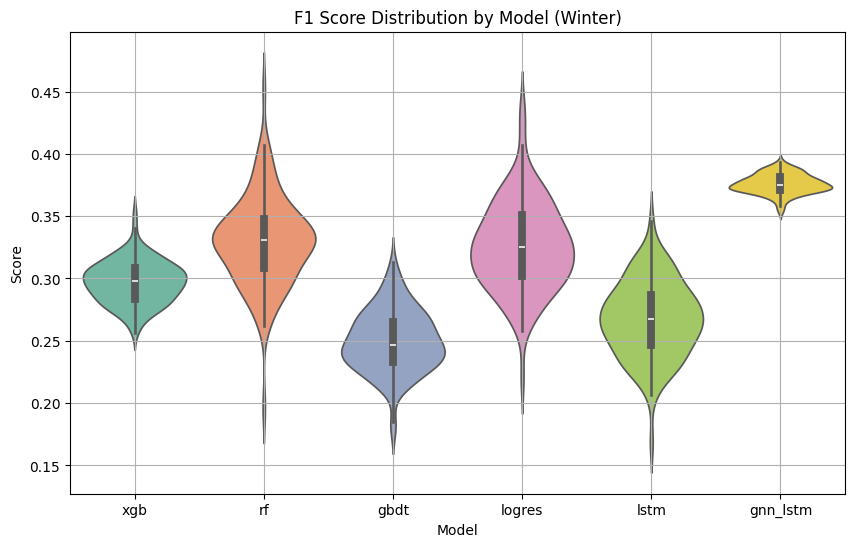

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


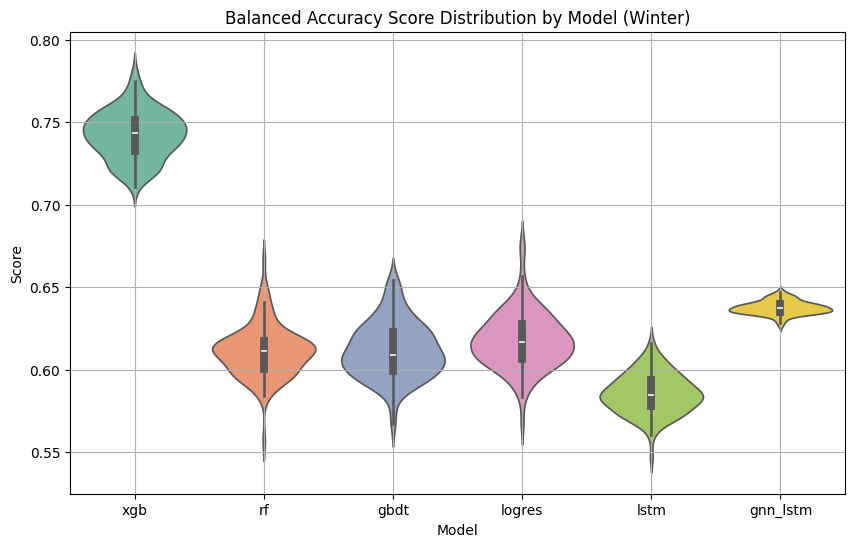

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


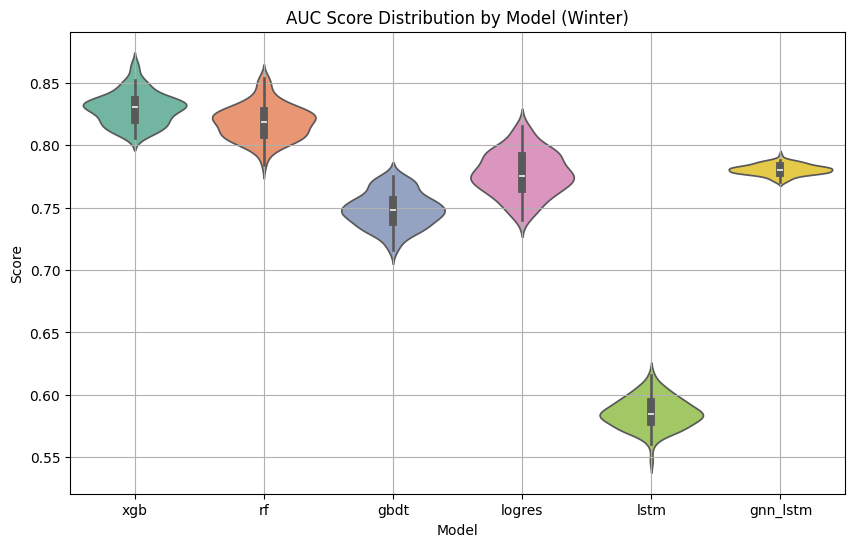

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
608/608 ━━━━━━━━

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


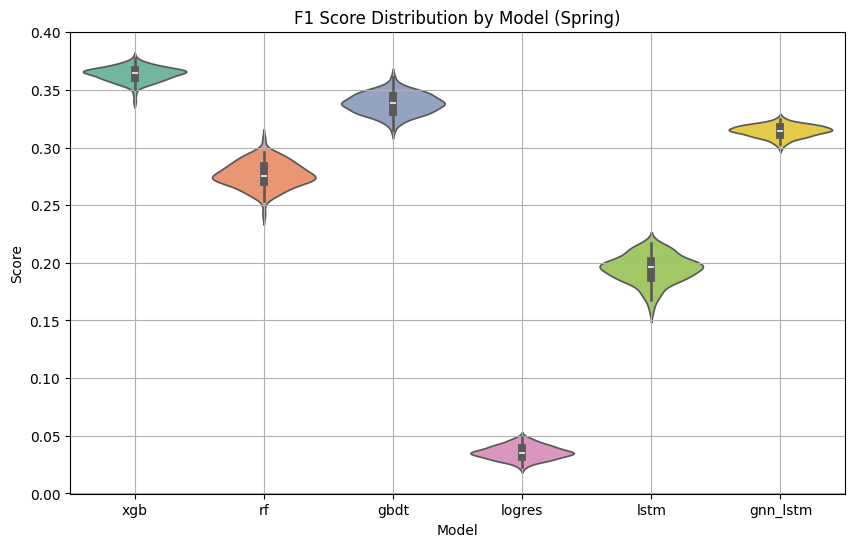

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


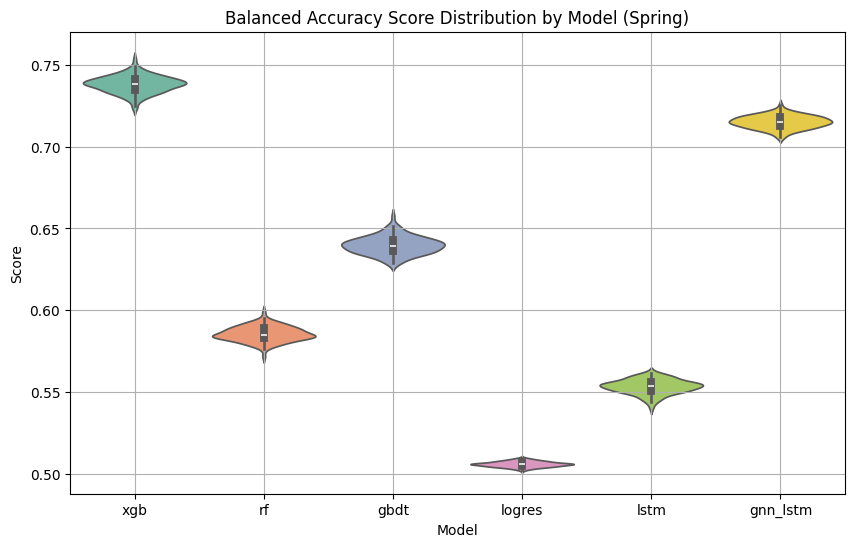

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


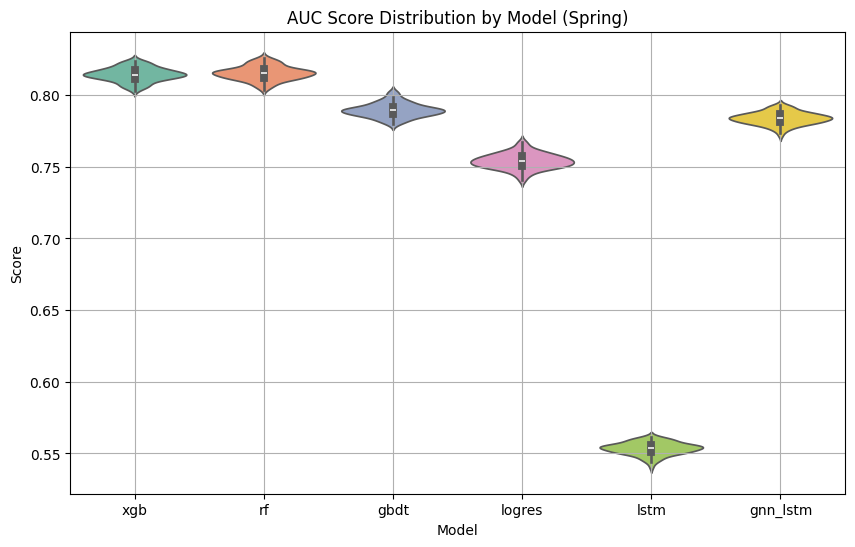

597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
597/597 ━━━━━━━━

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


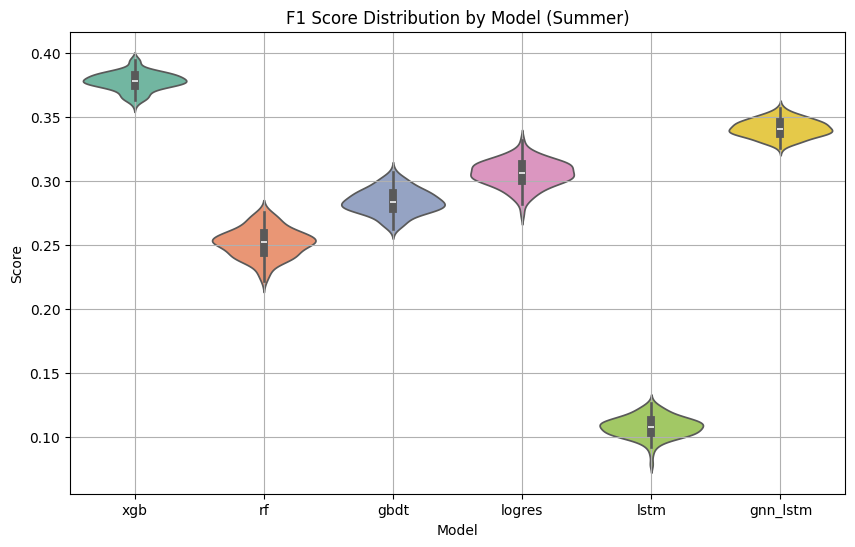

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


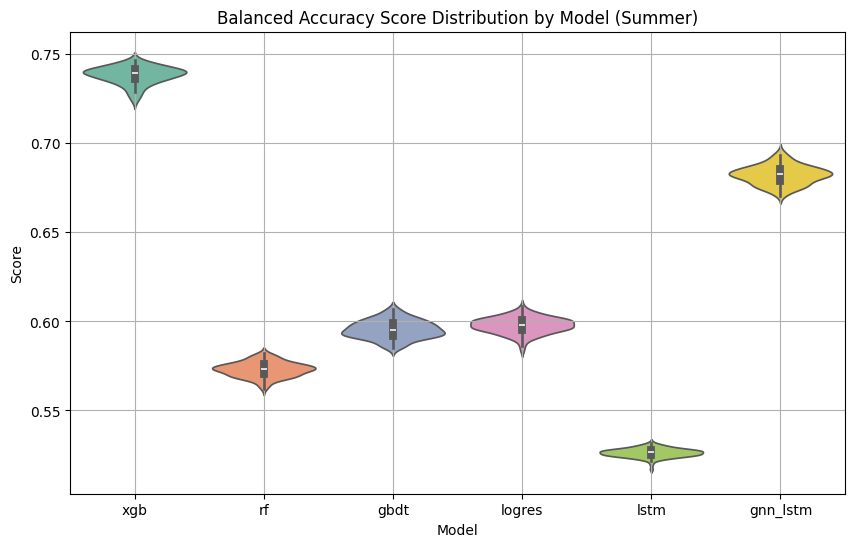

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


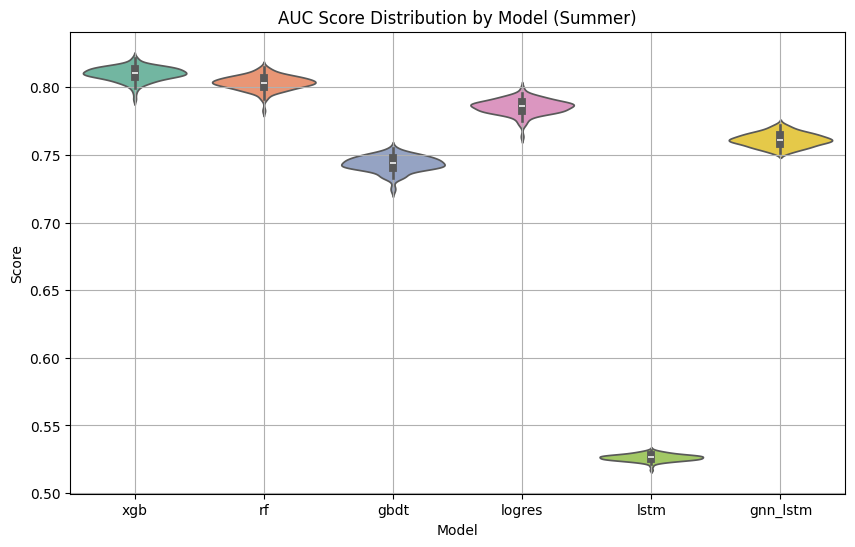

598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


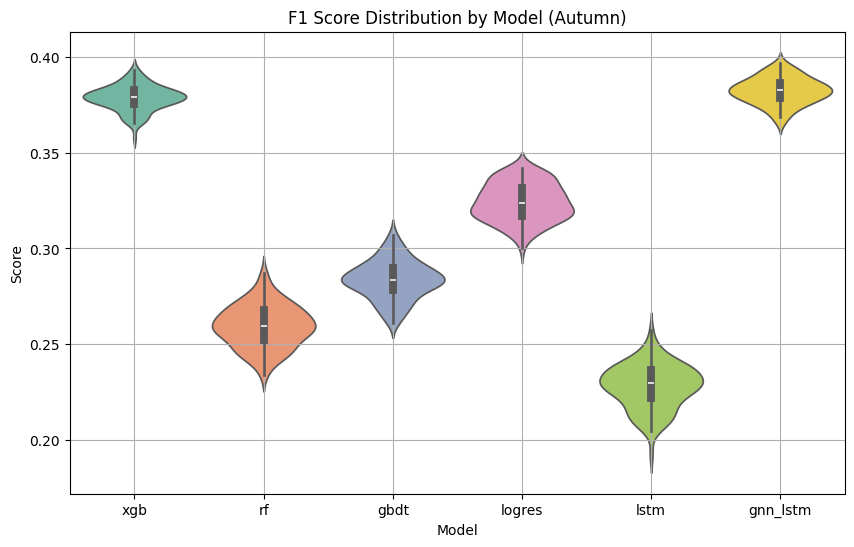

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


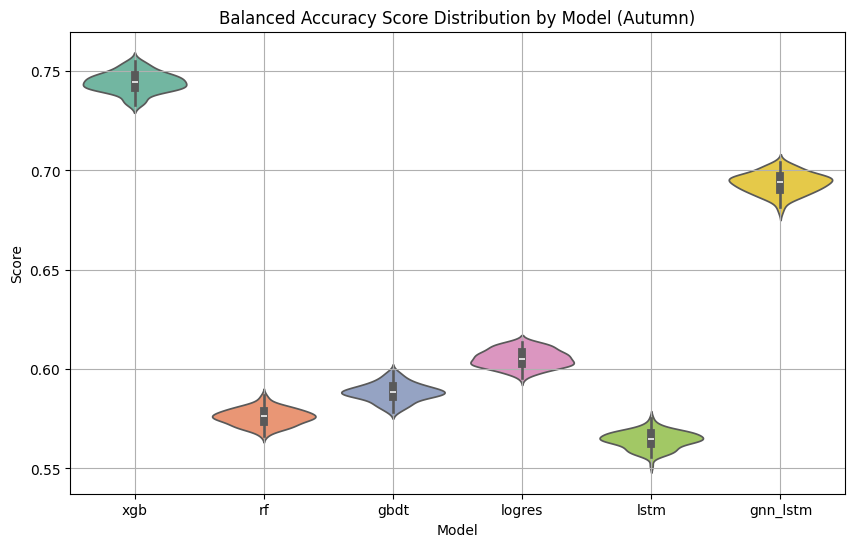

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2730117849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Model', y='Score', inner='box', palette='Set2')


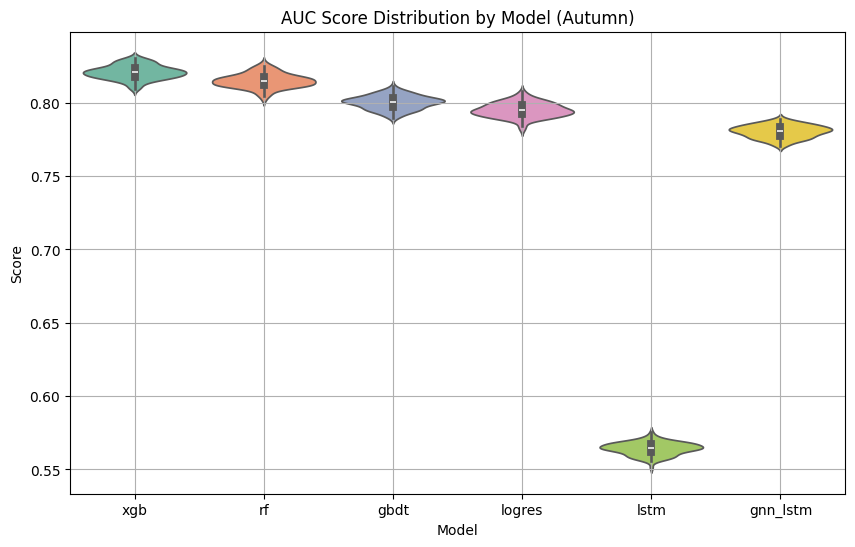

In [134]:
from scipy.stats import ttest_ind

def bootstrap_metrics_scores(model, X, y, is_lstm=False, n_bootstraps=100, seed=42):
    rng = np.random.RandomState(seed)
    scores = {
        'f1': [], 'precision': [], 'recall': [], 'balanced_acc': [], 'auc': []
    }
    
    for _ in range(n_bootstraps):
        indices = rng.choice(len(X), len(X), replace=True)
        X_sample = X.iloc[indices]
        y_sample = y.iloc[indices].astype(int)

        if is_lstm:
            scaler = StandardScaler()
            X_sample_reset = X_sample.reset_index(drop=True)  # Ensure alignment
            y_sample = y_sample.reset_index(drop=True)        # Align labels
    
            X_scaled = scaler.fit_transform(X_sample_reset)
            X_np = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
    
            y_pred = model.predict(X_np)
            y_pred_prob = np.argmax(y_pred, axis=1)
        else:
            y_pred_prob = model.predict_proba(X_sample)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_sample)

        y_pred = (y_pred_prob >= 0.5).astype(int)

        scores['f1'].append(f1_score(y_sample, y_pred))
        scores['precision'].append(precision_score(y_sample, y_pred))
        scores['recall'].append(recall_score(y_sample, y_pred))
        scores['balanced_acc'].append(balanced_accuracy_score(y_sample, y_pred))
        try:
            scores['auc'].append(roc_auc_score(y_sample, y_pred_prob))
        except:
            scores['auc'].append(np.nan)

    return scores

def get_confidence_interval(data, ci=95):
    lower = np.percentile(data, (100 - ci) / 2)
    upper = np.percentile(data, 100 - (100 - ci) / 2)
    return lower, upper

def compare_models(models, X_test_dict, y_test, season, gnn_results=None):
    all_metrics = {}

    for name, model in models.items():
        is_lstm = (name == 'lstm')
        scores = bootstrap_metrics_scores(model, X_test_dict[name], y_test, is_lstm=is_lstm)
        all_metrics[name] = scores

    # Include GNN_LSTM scores from gnn_results if provided
    if gnn_results is not None:
        season_gnn = gnn_results[gnn_results['Season'] == season]
        gnn_scores = {
            'f1': season_gnn[season_gnn['Metric'] == 'f1']['Values'].values[0],
            'precision': season_gnn[season_gnn['Metric'] == 'precision']['Values'].values[0],
            'recall': season_gnn[season_gnn['Metric'] == 'recall']['Values'].values[0],
            'balanced_acc': season_gnn[season_gnn['Metric'] == 'ba']['Values'].values[0],
            'auc': season_gnn[season_gnn['Metric'] == 'auc']['Values'].values[0],
        }
        all_metrics['gnn_lstm'] = gnn_scores

    model_names = list(all_metrics.keys())
    
    print(f"\n--- Paired t-tests on F1 for {season} ---")
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            t_stat, p_val = ttest_ind(all_metrics[m1]['f1'], all_metrics[m2]['f1'], alternative='greater')
            print(f"{m1} vs {m2}: t = {t_stat:.3f}, p = {p_val:.4f}")
    
    # Print confidence intervals
    print(f"\n--- Bootstrap Confidence Intervals ({season}) ---")
    for name, scores in all_metrics.items():
        print(f"\n{name}:")
        for metric in scores:
            mean = np.mean(scores[metric])
            low, high = get_confidence_interval(scores[metric])
            print(f"{metric}: {mean:.3f} ({low:.3f}–{high:.3f})")

    return {k: v['f1'] for k, v in all_metrics.items()}, {k: v['balanced_acc'] for k, v in all_metrics.items()}, {k: v['auc'] for k, v in all_metrics.items()}  # Return only F1 scores

# Dictionary to store F1 scores for each season
season_f1_scores = {}
season_ba_scores = {}
season_auc_scores = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    year_split = split_season_by_year(X, season)
    train_data = pd.concat([year_split[year] for year in year_split if year != f'{season} 2024'])
    test_data = year_split[f'{season} 2024']
    
    y_train = train_data['Disrupted'].astype(int)
    y_test = test_data['Disrupted'].astype(int)
    
    selected_features = {
        'xgb': feature_selection_xgb[season],
        'rf': rf_top_features[season],
        'gbdt': feature_selection_gb[season],
        'logres': lr_top_features[season],
        'lstm': lstm_features[season]  # you must define this if needed
    }

    models = {}
    X_test_dict = {}

    for model_name in ['xgb', 'rf', 'gbdt', 'logres']:
        X_train = train_data[selected_features[model_name]]
        X_test = test_data[selected_features[model_name]]
        
        if model_name == 'xgb':
            model = XGBClassifier(random_state=42, **xgb_params[season])
        elif model_name == 'rf':
            model = RandomForestClassifier(random_state=42, **rf_params[season])
        elif model_name == 'gbdt':
            model = GradientBoostingClassifier(random_state=42, **gb_params[season])
        elif model_name == 'logres':
            model = LogisticRegression(random_state=42, **lr_params[season])
        
        model.fit(X_train, y_train)
        models[model_name] = model
        X_test_dict[model_name] = X_test

    # Add LSTM
    lstm_model = lstm_models_trained[season]
    X_test_lstm = test_data[selected_features['lstm']]
    X_test_dict['lstm'] = X_test_lstm
    models['lstm'] = lstm_model

    # Compare models
    f1_scores, ba_scores, auc_scores = compare_models(models, X_test_dict, y_test, season, gnn_results=gnn_df)
    plot_scores(f1_scores, season=season, scores='F1')
    plot_scores(ba_scores, season=season, scores='Balanced Accuracy')
    plot_scores(auc_scores, season=season, scores='AUC')
    season_f1_scores[season] = {k: np.mean(v) for k, v in f1_scores.items()}
    season_ba_scores[season] = {k: np.mean(v) for k, v in ba_scores.items()}
    season_auc_scores[season] = {k: np.mean(v) for k, v in auc_scores.items()}